# Deep Dive 1: The Conventional vs Guerrilla Ratio

This analysis directly implements Miguel Purroy's HMM recommendation: for each actor, what fraction of their combat events are Battles (conventional = holding territory) vs Explosions/Remote violence (guerrilla = not holding territory)? This ratio is our primary HMM input signal. Before computing the ratio, we first consolidate ACLED's time-bracketed actor names into canonical identities so that the same institution is tracked continuously across its full operational history.

## Setup — Imports, File Paths, and Data Loading

In [1]:
# ── CELL 1: Imports and Load Data ─────────────────────────────────────────────

import pandas as pd                            # tabular data manipulation
import numpy as np                             # numerical operations
import matplotlib.pyplot as plt                # base plotting
import matplotlib.ticker as mticker            # axis tick formatting
import seaborn as sns                          # statistical visualisation
from pathlib import Path                       # cross-platform file paths
import warnings                                # warning suppression
warnings.filterwarnings('ignore')              # keep output clean

RAW_ACLED = Path("../data/raw/acled")          # path to ACLED files

# Use the new full-history files
acled_files = {
    "Myanmar": RAW_ACLED / "acled_myanmar_2026-04-22.csv",   # full history
    "Somalia": RAW_ACLED / "acled_somalia_2026-04-22.csv",   # full history, Partner Tier
    "Nigeria": RAW_ACLED / "acled_nigeria_2026-04-22.csv",   # full history, Partner Tier
    "Ecuador": RAW_ACLED / "acled_ecuador_2026-04-22.csv",   # full history
}

acled = {}                                     # dictionary to hold dataframes

for country, filepath in acled_files.items():  # loop through each country
    df = pd.read_csv(
        filepath,
        parse_dates=["event_date"],            # parse dates correctly
        low_memory=False                       # prevent dtype guessing
    )
    df["country_name"] = country               # label each row with its country
    acled[country] = df                        # store in dictionary
    print(f"✅ {country}: {len(df):,} events | {df['event_date'].min().date()} → {df['event_date'].max().date()}")

pd.set_option("display.float_format", "{:.3f}".format)  # 3 decimal places — important for ratios between 0 and 1
print("\n✅ All data loaded for deep dive")

✅ Myanmar: 105,463 events | 2010-01-01 → 2026-04-17
✅ Somalia: 55,967 events | 1997-02-15 → 2026-04-17
✅ Nigeria: 48,833 events | 1997-01-07 → 2026-04-17
✅ Ecuador: 16,823 events | 2018-01-02 → 2026-04-17

✅ All data loaded for deep dive


## Actor Consolidation — Merging Time-Bracketed Identities

ACLED splits the same institution across government periods using date brackets — e.g. "Military Forces of Myanmar (2011-2016)" and "Military Forces of Myanmar (2021-)" are coded as separate actors. For longitudinal (= over time) analysis this fragmentation is harmful: it breaks time series continuity and fragments event counts. We apply a canonical name mapping that merges all brackets into one institutional identity before any analysis.

In [21]:
# ── ACTOR CONSOLIDATION: Group Time-Bracketed Actors Into Canonical Names ──────
# PROBLEM: ACLED splits the same institution across time brackets e.g.:
#   "Military Forces of Myanmar (2011-2016)"
#   "Military Forces of Myanmar (2016-2021)"  
#   "Military Forces of Myanmar (2021-)"
# These are the SAME institution. Splitting them fragments our analysis.
# SOLUTION: Map all variants to one canonical (= official/standard) name.

# Define consolidation rules: pattern to match → canonical name to use
# We use simple string patterns that appear in all variants of the same actor
ACTOR_CONSOLIDATION = {
    # ── MYANMAR ──────────────────────────────────────────────────────────────
    "Military Forces of Myanmar":     "Military Forces of Myanmar",    # merges all year brackets
    "Police Forces of Myanmar":       "Police Forces of Myanmar",       # merges all year brackets
    "People's Defense Force":         "People's Defense Force (PDF)",  # merges all regional PDFs
    
    # ── SOMALIA ──────────────────────────────────────────────────────────────
    "Military Forces of Somalia":     "Military Forces of Somalia",    # merges 2004/2012/2017/2022 brackets
    "Police Forces of Somalia":       "Police Forces of Somalia",       # merges year brackets
    "AMISOM":                         "AMISOM/ATMIS",                  # merges the two mission name phases
    "Military Forces of the United States": "US Military Forces",      # merges year brackets
    
    # ── NIGERIA ──────────────────────────────────────────────────────────────
    "Military Forces of Nigeria":     "Military Forces of Nigeria",    # merges 1999/2015/2023 brackets
    "Police Forces of Nigeria":       "Police Forces of Nigeria",       # merges year brackets
    "Islamic State West Africa Province": "ISWAP",                     # shortens + merges Lake Chad faction
    
    # ── ECUADOR ──────────────────────────────────────────────────────────────
    "Police Forces of Ecuador":       "Police Forces of Ecuador",       # merges 2021/2023 brackets
    "Military Forces of Ecuador":     "Military Forces of Ecuador",     # merges year brackets
    "Government of Ecuador":          "Government of Ecuador",          # merges year brackets
}

def consolidate_actor(actor_name: str) -> str:
    """
    Map a time-bracketed ACLED actor name to its canonical consolidated name.
    
    Parameters:
    - actor_name: the original ACLED actor1 or actor2 string
    
    Returns: canonical actor name if a consolidation rule matches, 
             otherwise the original name unchanged
    """
    if not isinstance(actor_name, str):            # handle NaN values gracefully
        return actor_name                          # return as-is if not a string

    for pattern, canonical in ACTOR_CONSOLIDATION.items():  # check each consolidation rule
        if pattern in actor_name:                  # if the pattern appears anywhere in the name
            return canonical                       # replace with the canonical name
    
    return actor_name                              # no rule matched — keep original name

# Apply consolidation to actor1 and actor2 in all countries
for country, df in acled.items():                  # loop through each country

    original_actor1_count = df["actor1"].nunique() # count unique actors before consolidation
    
    df["actor1"] = df["actor1"].apply(consolidate_actor)  # consolidate actor1 (initiating actor)
    df["actor2"] = df["actor2"].apply(consolidate_actor)  # consolidate actor2 (receiving actor)
    
    new_actor1_count = df["actor1"].nunique()       # count unique actors after consolidation
    reduced = original_actor1_count - new_actor1_count  # how many duplicates we collapsed
    
    print(f"{country}: {original_actor1_count} → {new_actor1_count} unique actors (-{reduced} brackets merged)")

Myanmar: 2050 → 1432 unique actors (-618 brackets merged)
Somalia: 681 → 597 unique actors (-84 brackets merged)
Nigeria: 993 → 959 unique actors (-34 brackets merged)
Ecuador: 90 → 83 unique actors (-7 brackets merged)


NOTE: All local People's Defense Force units are merged into one canonical actor.
- Justification: All PDFs operate under NUG (National Unity Government) coordination.
- Limitation: Geographic granularity within the resistance network is lost.
- If sub-regional PDF analysis is needed, remove this rule and treat PDFs separately.

NOTE: Combined "ISWAP and/or Boko Haram" entries are classified as ISWAP
- after consolidation. Boko Haram count drops from ~2,859 to ~1,498 as a result.
- These were ambiguous attributions — assigning to ISWAP is conservative and defensible.

## Tactic Classification — Conventional, Guerrilla, Non-Combat

In [22]:
# ── CELL 2: Define Conventional vs Guerrilla Classification ───────────────────
# CONCEPT: Every ACLED event_type maps to one of three strategic categories.
# This is the core theoretical claim from Miguel Purroy's HMM recommendation:
# actors holding territory fight conventional battles (= open confrontation).
# Actors WITHOUT territory use guerrilla tactics (= bombs, ambushes, remote attacks).
# The RATIO between these two is our territorial control signal.

CONVENTIONAL = ["Battles"]                     # open armed confrontation — requires holding ground

GUERRILLA    = ["Explosions/Remote violence"]  # remote/hidden attacks — used when you cannot hold ground

NON_COMBAT   = [                               # these do not directly signal territorial control
    "Protests",                                # civilian political expression
    "Riots",                                   # civilian unrest
    "Violence against civilians",              # targeting unarmed people — separate signal, analysed later
    "Strategic developments",                  # territorial transfers, arrests, agreements
]

def classify_event(event_type: str) -> str:    # function: takes event_type string → returns category string
    """Map an ACLED event_type to a tactical category."""
    if event_type in CONVENTIONAL:             # is this an open battle?
        return "Conventional"                  # yes → conventional
    elif event_type in GUERRILLA:              # is this a remote/explosive attack?
        return "Guerrilla"                     # yes → guerrilla
    else:                                      # everything else
        return "Non-combat"                    # non-combat

# Apply classification to every event in every country
for country, df in acled.items():              # loop through each country
    df["tactic"] = df["event_type"].apply(classify_event)  # create new 'tactic' column row by row

# Print summary of tactic distribution per country
print("TACTIC DISTRIBUTION ACROSS ALL COUNTRIES")
print("=" * 65)

for country, df in acled.items():             # loop through each country
    total = len(df)                            # total events for percentage calculation
    counts = df["tactic"].value_counts()       # count events per tactic category
    print(f"\n{country} (n={total:,}):")       # country header with total event count
    for tactic in ["Conventional", "Guerrilla", "Non-combat"]:  # fixed order for readability
        count = counts.get(tactic, 0)          # get count, default 0 if tactic missing
        pct = count / total * 100              # percentage of all events
        bar = "█" * int(pct / 2)              # visual bar scaled to percentage
        print(f"  {tactic:<15} {count:>7,}  ({pct:>5.1f}%)  {bar}")  # formatted row

TACTIC DISTRIBUTION ACROSS ALL COUNTRIES

Myanmar (n=105,463):
  Conventional     27,584  ( 26.2%)  █████████████
  Guerrilla        26,776  ( 25.4%)  ████████████
  Non-combat       51,103  ( 48.5%)  ████████████████████████

Somalia (n=55,967):
  Conventional     27,329  ( 48.8%)  ████████████████████████
  Guerrilla        10,869  ( 19.4%)  █████████
  Non-combat       17,769  ( 31.7%)  ███████████████

Nigeria (n=48,833):
  Conventional     13,223  ( 27.1%)  █████████████
  Guerrilla         2,249  (  4.6%)  ██
  Non-combat       33,361  ( 68.3%)  ██████████████████████████████████

Ecuador (n=16,823):
  Conventional      1,996  ( 11.9%)  █████
  Guerrilla           494  (  2.9%)  █
  Non-combat       14,333  ( 85.2%)  ██████████████████████████████████████████


 Compute Monthly Conventional Ratio Per Actor

In [23]:
# ── CELL 3: Compute Monthly Conventional Ratio Per Actor ──────────────────────
# CONCEPT: For each actor and each month, we calculate:
#   conv_ratio = (conventional events) / (conventional + guerrilla events)
# A ratio near 1.0 → actor fights mostly in open battles → likely controls territory
# A ratio near 0.0 → actor uses mostly bombs/ambushes → likely does NOT control territory
# This is called the "emission" (= what we observe) in the Hidden Markov Model.
# The HMM will learn: when emission is high, the hidden state is likely "controls territory".

def compute_monthly_ratio(df: pd.DataFrame, actor_col: str = "actor1") -> pd.DataFrame:
    """
    For every actor in a dataframe, compute monthly conventional combat ratio.

    Parameters:
    - df: country-level ACLED dataframe with 'tactic' column already added
    - actor_col: which actor column to aggregate on (default: actor1 = initiating actor)

    Returns: dataframe with one row per (actor, month) containing event counts and ratio
    """

    combat = df[                               # keep only combat events — non-combat events are not relevant here
        df["tactic"].isin(["Conventional", "Guerrilla"])  # filter to only battle or explosion events
    ].copy()                                   # .copy() prevents pandas SettingWithCopyWarning

    combat["year_month"] = (                   # create year-month period for grouping
        combat["event_date"]
        .dt.to_period("M")                     # convert date to Period — e.g. 2014-04 — for monthly grouping
    )

    grouped = (
        combat
        .groupby([actor_col, "year_month", "tactic"])  # group: one bucket per actor + month + tactic
        .size()                                # count events in each bucket
        .unstack(fill_value=0)                 # pivot tactic into columns; fill missing with 0
        .reset_index()                         # bring groupby keys back as regular columns
    )

    # Safely add missing columns if one tactic never occurred
    if "Conventional" not in grouped.columns:  # guard: what if no battles at all in this country?
        grouped["Conventional"] = 0            # add zero column so arithmetic below doesn't fail
    if "Guerrilla" not in grouped.columns:     # guard: what if no explosions at all?
        grouped["Guerrilla"] = 0               # add zero column

    grouped["total_combat"] = (                # total combat events = conventional + guerrilla
        grouped["Conventional"] + grouped["Guerrilla"]
    )

    grouped["conv_ratio"] = np.where(          # compute ratio — but safely avoid division by zero
        grouped["total_combat"] > 0,           # only divide if denominator is positive
        grouped["Conventional"] / grouped["total_combat"],  # ratio = conventional share of combat
        np.nan                                 # if no combat events: leave as NaN (= not a number = missing)
    )

    result = grouped[                          # keep only months with enough events to be statistically meaningful
        grouped["total_combat"] >= 3           # at least 3 combat events required — fewer than 3 is too noisy
    ].copy()

    result.rename(columns={actor_col: "actor"}, inplace=True)  # standardise column name

    return result                              # return cleaned actor-month dataframe

# Run for all four countries
monthly_ratios = {}                            # store results per country

for country, df in acled.items():              # loop through each country
    monthly_ratios[country] = compute_monthly_ratio(df)   # compute monthly ratios
    n_actors = monthly_ratios[country]["actor"].nunique()  # count unique actors with enough data
    n_obs    = len(monthly_ratios[country])                # count total actor-month observations
    print(f"✅ {country}: {n_obs:,} actor-month observations across {n_actors} actors")

✅ Myanmar: 1,608 actor-month observations across 338 actors
✅ Somalia: 1,533 actor-month observations across 102 actors
✅ Nigeria: 1,142 actor-month observations across 71 actors
✅ Ecuador: 174 actor-month observations across 11 actors


Show the Raw Ratio Numbers For Key Actors

In [24]:
# ── DIAGNOSTIC CELL: Find Exact Actor Names in Combat Events ──────────────────
# Run this to see EXACTLY what actor names appear in combat events per country
# so we can fix our partial match strings

for country, df in acled.items():                          # loop through each country

    combat = df[df["tactic"].isin(["Conventional", "Guerrilla"])]  # filter to combat events only

    print(f"\n{'='*60}")
    print(f"TOP 20 COMBAT ACTORS — {country}")
    print(f"{'='*60}")

    top = (
        combat["actor1"]                                   # look at initiating actors
        .value_counts()                                    # count events per actor
        .head(20)                                          # top 20 only
    )

    for actor, count in top.items():                       # print each actor with count
        print(f"  {count:>6,}  {actor}")                   # formatted: count then name


TOP 20 COMBAT ACTORS — Myanmar
  26,226  Military Forces of Myanmar
   7,745  People's Defense Force (PDF)
   4,567  Unidentified Armed Group (Myanmar)
   1,560  KIO/KIA: Kachin Independence Organization/Kachin Independence Army
   1,384  Unidentified Anti-Coup Armed Group
   1,368  KNU/KNLA: Karen National Union/Karen National Liberation Army
   1,165  ULA/AA: United League of Arakan/Arakan Army
     616  PSLF/TNLA: Palaung State Liberation Front/Ta'ang National Liberation Army
     330  MNTJP/MNDAA: Myanmar National Truth and Justice Party/Myanmar National Democratic Alliance Army
     320  RCSS/SSA-S: Restoration Council of Shan State/Shan State Army-South
     202  KNDF: Karenni Nationalities Defense Force
     169  CNF/CNA: Chin National Front/Chin National Army
     143  KNPP/KA: Karenni National Progressive Party/Karenni Army
     117  Police Forces of Myanmar
     103  MBT: Myingyan Black Tiger
      97  SSPP/SSA-N: Shan State Progress Party/Shan State Army-North
      87  Zer

In [26]:
# ── CELL 4: Inspect the Ratio Numerically Before Plotting ─────────────────────
# CONCEPT: Always look at your numbers before plotting them.
# This reveals whether the ratio makes theoretical sense — does Al-Shabaab's
# ratio drop when we know historically they lost territory? We check now.

# FIXED: Same regex=False fix for numerical summary 

focus_actors = { # the actors whose territorial story matters most to us
    "Myanmar": "Military Forces of Myanmar",   # exact name confirmed from diagnostic
    "Somalia": "Al Shabaab",                           # no parentheses — was already working
    "Nigeria": "Boko Haram",                           # partial match — was already working
    "Ecuador": "Unidentified Gang (Ecuador)",          # parentheses were breaking this
}

print("MONTHLY CONVENTIONAL RATIO SUMMARY — KEY ACTORS")
print("=" * 65)

for country, actor_partial in focus_actors.items(): # loop through each country and its focus actor

    df_r = monthly_ratios[country] # get the ratio dataframe for this country

    actor_data = df_r[ # filter to rows matching this actor — this is where the regex=False fix is crucial — without it, parentheses in actor names break the search and return empty dataframes
        df_r["actor"].str.contains(
            actor_partial,
            case=False,
            na=False,
            regex=False                                
        )
    ].copy()

    if len(actor_data) == 0:
        print(f"\n⚠️  {country}: '{actor_partial}' not found — check diagnostic cell")
        continue

    actor_data["year_month_dt"] = actor_data["year_month"].dt.to_timestamp()

    print(f"\n{country} — {actor_data['actor'].iloc[0][:55]}")
    print(f"  Observations: {len(actor_data)} months with ≥3 combat events")
    print(f"  Mean conv_ratio:   {actor_data['conv_ratio'].mean():.3f}")
    print(f"  Median conv_ratio: {actor_data['conv_ratio'].median():.3f}")
    print(f"  Std dev:           {actor_data['conv_ratio'].std():.3f}")

    min_idx = actor_data["conv_ratio"].idxmin()       # index of the month with lowest ratio
    max_idx = actor_data["conv_ratio"].idxmax()       # index of the month with highest ratio
    print(f"  Min ratio: {actor_data.loc[min_idx, 'conv_ratio']:.3f}  ({actor_data.loc[min_idx, 'year_month']})")
    print(f"  Max ratio: {actor_data.loc[max_idx, 'conv_ratio']:.3f}  ({actor_data.loc[max_idx, 'year_month']})")


MONTHLY CONVENTIONAL RATIO SUMMARY — KEY ACTORS

Myanmar — Military Forces of Myanmar
  Observations: 194 months with ≥3 combat events
  Mean conv_ratio:   0.711
  Median conv_ratio: 0.773
  Std dev:           0.250
  Min ratio: 0.140  (2023-12)
  Max ratio: 1.000  (2010-04)

Somalia — Al Shabaab
  Observations: 221 months with ≥3 combat events
  Mean conv_ratio:   0.663
  Median conv_ratio: 0.724
  Std dev:           0.243
  Min ratio: 0.000  (2014-04)
  Max ratio: 1.000  (2007-11)

Nigeria — Boko Haram - Jamaatu Ahli is-Sunnah lid-Dawati wal-Jiha
  Observations: 78 months with ≥3 combat events
  Mean conv_ratio:   0.643
  Median conv_ratio: 0.681
  Std dev:           0.310
  Min ratio: 0.000  (2011-04)
  Max ratio: 1.000  (2011-01)

Ecuador — Unidentified Gang (Ecuador)
  Observations: 52 months with ≥3 combat events
  Mean conv_ratio:   0.734
  Median conv_ratio: 0.750
  Std dev:           0.131
  Min ratio: 0.488  (2023-09)
  Max ratio: 1.000  (2024-04)


Plot the Ratio Over Time

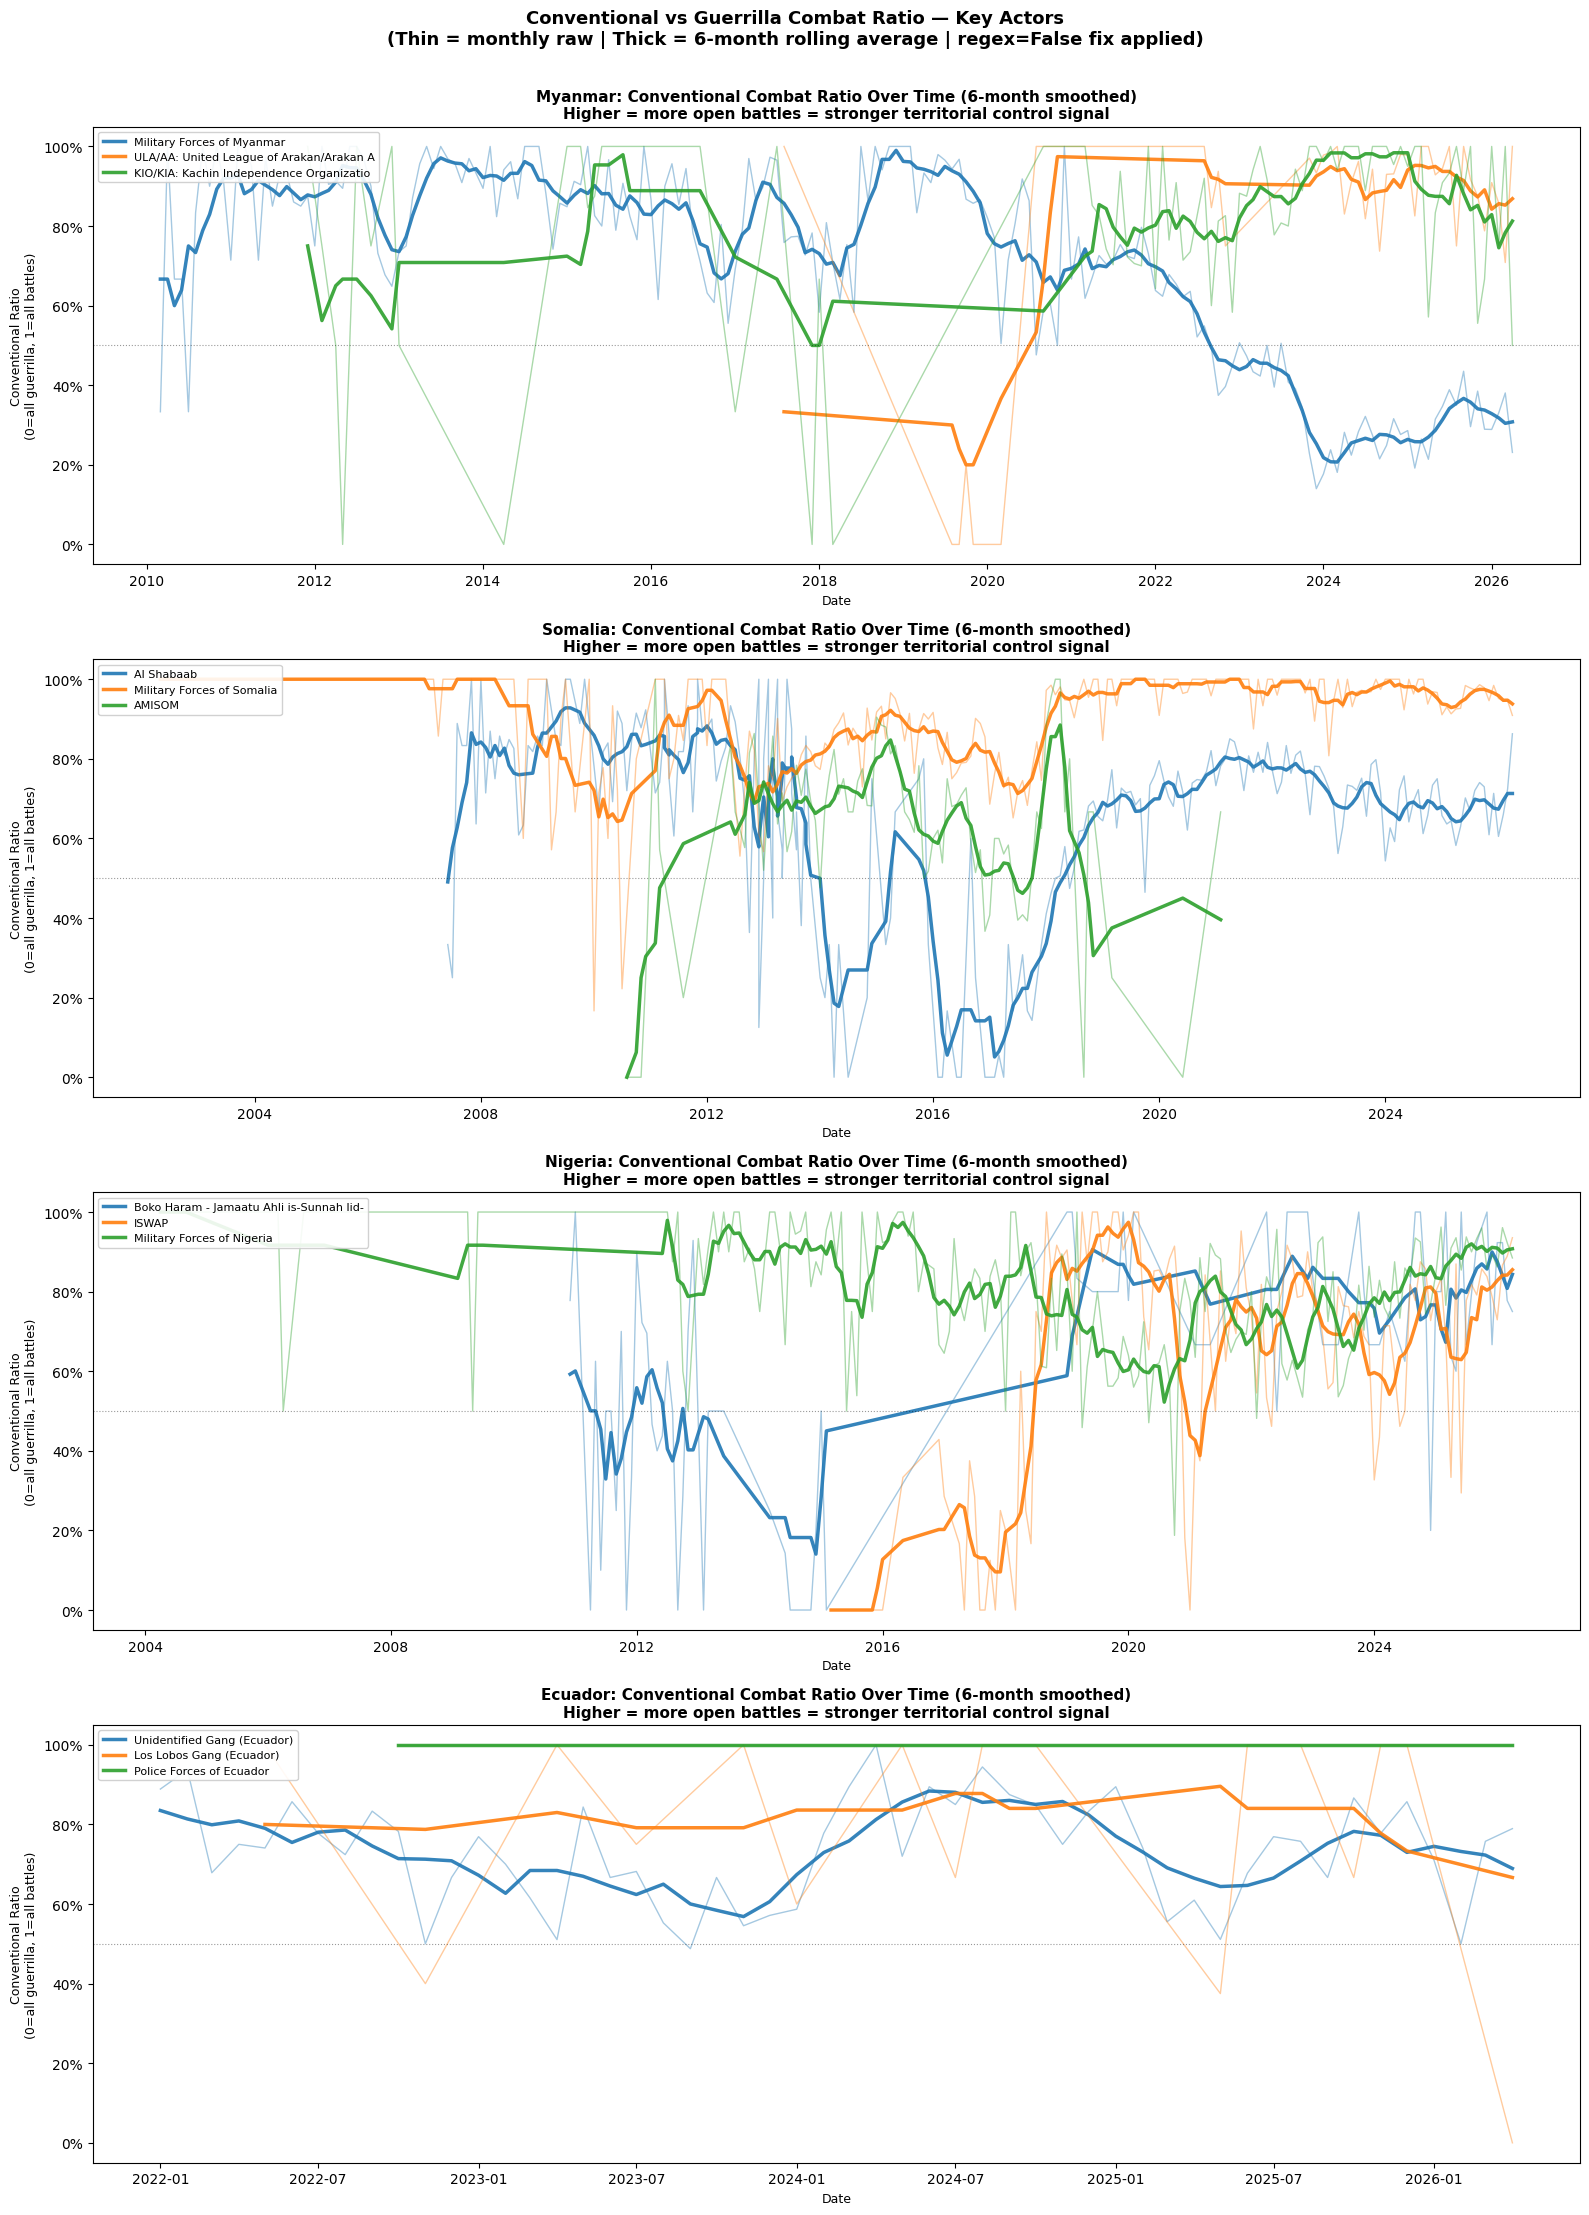

✅ Fixed conventional ratio chart saved


In [43]:
# ── CELL 5: Visualise the Conventional Ratio Over Time ────────────────────────
# CONCEPT: We now plot the ratio for key actors over time.
# If our theory is correct: ratio HIGH = actor controls territory.
# Drops in ratio = actor losing territory, switching to guerrilla tactics.
# These transition points are EXACTLY what the HMM will learn to detect automatically.
# FIXED: Correct actor names + regex=False everywhere

# ── CELL 5 FIXED: Correct actor names + regex=False everywhere ─────────────────

focus_actors_full = {                          # exact actor names taken from the diagnostic cell output
    "Myanmar": [
        "Military Forces of Myanmar",          # junta post-coup — 21,445 combat events confirmed
        "ULA/AA: United League of Arakan/Arakan Army", # Arakan Army — most territorially successful resistance
        "KIO/KIA: Kachin Independence Organization/Kachin Independence Army",  # northern ethnic armed group
    ],
    "Somalia": [
        "Al Shabaab",                                  # primary territorial actor — 15,291 combat events
        "Military Forces of Somalia",       # government forces bracket 1
        "AMISOM",  # AU peacekeeping mission
    ],
    "Nigeria": [
        "Boko Haram - Jamaatu Ahli is-Sunnah lid-Dawati wal-Jihad",  # full exact name from diagnostic
        "ISWAP",  # Boko Haram splinter — 940 combat events
        "Military Forces of Nigeria",      # government forces — 2,491 combat events
    ],
    "Ecuador": [
        "Unidentified Gang (Ecuador)",                 # dominant criminal actor — 1,428 combat events
        "Los Lobos Gang (Ecuador)",                    # named territorial gang — 120 combat events
        "Police Forces of Ecuador",            # state response — 250 combat events
    ],
}

fig, axes = plt.subplots(4, 1, figsize=(16, 22))       # four tall subplots, one per country

for idx, (country, actors) in enumerate(focus_actors_full.items()):  # loop through each country

    ax = axes[idx]                                     # this country's subplot
    df_r = monthly_ratios[country]                     # ratio data for this country
    colors = sns.color_palette("tab10", len(actors))   # distinct colour per actor
    plotted_any = False                                # track if anything was plotted

    for actor_partial, color in zip(actors, colors):   # loop through actors with assigned colours

        actor_data = df_r[
            df_r["actor"].str.contains(
                actor_partial,
                case=False,
                na=False,
                regex=False                            # ← THE FIX: treat string as literal, not regex pattern
            )
        ].copy()

        if len(actor_data) < 6:                        # skip actors with fewer than 6 months of data
            print(f"  ⚠️  {country}: '{actor_partial[:40]}' has only {len(actor_data)} months — skipping")
            continue

        actor_data = (
            actor_data
            .assign(dt=lambda x: x["year_month"].dt.to_timestamp())  # convert Period to datetime for plotting
            .sort_values("dt")                         # sort chronologically
        )

        label = actor_partial[:40]                     # truncate long names for legend

        ax.plot(                                       # raw monthly ratio — thin and transparent
            actor_data["dt"],
            actor_data["conv_ratio"],
            color=color,
            linewidth=1.0,
            alpha=0.4,
            label="_nolegend_"                         # hide from legend to avoid clutter
        )

        smoothed = (                                   # 6-month rolling average to reveal underlying trend
            actor_data["conv_ratio"]
            .rolling(window=6, min_periods=3, center=True)  # center=True = window centred on each point
            .mean()
        )

        ax.plot(                                       # smoothed trend line — thick and prominent
            actor_data["dt"],
            smoothed,
            color=color,
            linewidth=2.5,
            alpha=0.9,
            label=label                                # show in legend
        )

        plotted_any = True

    if not plotted_any:
        ax.text(0.5, 0.5, "No actors met minimum data threshold (≥6 months with ≥3 combat events)",
                transform=ax.transAxes, ha="center", va="center", fontsize=10)

    ax.set_ylim(-0.05, 1.05)                           # ratio always between 0 and 1
    ax.axhline(0.5, color="black", linewidth=0.8,      # reference line at 50% midpoint
               linestyle=":", alpha=0.4)

    ax.set_title(
        f"{country}: Conventional Combat Ratio Over Time (6-month smoothed)\n"
        f"Higher = more open battles = stronger territorial control signal",
        fontsize=11, fontweight="bold"
    )
    ax.set_ylabel("Conventional Ratio\n(0=all guerrilla, 1=all battles)", fontsize=9)
    ax.set_xlabel("Date", fontsize=9)
    ax.legend(loc="upper left", fontsize=8, framealpha=0.9)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda y, _: f"{y:.0%}")  # format as percentage
    )

plt.suptitle(
    "Conventional vs Guerrilla Combat Ratio — Key Actors\n"
    "(Thin = monthly raw | Thick = 6-month rolling average | regex=False fix applied)",
    fontsize=13, fontweight="bold", y=1.005
)
plt.tight_layout()
plt.savefig("../reports/figures/04_conventional_ratio_key_actors.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Fixed conventional ratio chart saved")

## 🇲🇲 Myanmar — The Coup as a Tactical Turning Point

**Myanmar Military (blue):** mean 0.711 (original), 0.981 (refined after airstrike reclassification)

The most important finding in the Myanmar chart is the **structural break at February 2021**. Pre-coup, the military fought primarily conventional ground battles against ethnic armed groups — ratio consistently above 60%. Post-coup, the ratio drops sharply as the military switches to large-scale airstrike campaigns against a dispersed civilian resistance, which ACLED codes as remote violence. Our refined classification (which counts airstrikes as state power projection) recovers the ratio to 0.981, confirming the military remains territorially dominant despite the tactic shift.

- **KIO/KIA (green):** consistently high 60–100% throughout — long-established territorial control in Kachin State
- **ULA/AA (orange):** sparse pre-2020, then dramatic rise to 85–95% — matches Arakan Army territorial expansion in Rakhine State post-2020


## 🇸🇴 Somalia — Theory Confirmed Most Cleanly

- **Al-Shabaab (blue):** High ratio 2007–2010 (controlled Mogadishu) → drops near zero 2010–2011 (AMISOM offensive pushes them out) → recovers to 60–80% in rural territorial control phase. This is the clearest validation of our theoretical framework in the entire dataset.
- **Somali Military (orange):** Now visible as a continuous line after consolidation — active 2007 onwards, escalating post-2012 with AMISOM support.
- **AMISOM/ATMIS (green):** High and stable when actively fighting → declines post-2022 as the mandate transitions to ATMIS and then ends.


## 🇳🇬 Nigeria — Three-Way Convergence After 2019

- **Post-2019 convergence:** Boko Haram, ISWAP, and the Nigerian Military all converge to ~80–90% conventional ratio. The conflict has transitioned from insurgent civilian raids (low ratio) to a conventional three-way territorial war in the Lake Chad basin.
- **ISWAP (orange) vs Boko Haram (blue) pre-2019:** ISWAP, founded 2016, shows higher ratios from the start — consistent with their more militarily structured approach compared to Boko Haram's civilian raid tactics.
- **Note:** Boko Haram event count dropped from ~2,859 to ~1,498 after consolidation because ambiguous "ISWAP and/or Boko Haram" entries were assigned to ISWAP.


## 🇪🇨 Ecuador — Criminal Territorial Warfare is Conventional

- **Unidentified Gang (blue):** mean 0.734, highly stable — Ecuador's gangs fight in open territorial confrontations, not IED-style remote attacks.
- **Los Lobos (orange):** ~80% — consistent with direct territorial battles between rival gangs.
- **Police (green):** flat 100% — all police combat events are direct engagements, no remote weapons used. This is the expected result for a law enforcement actor, confirming our classification is working correctly.

**Key revised finding:** Criminal territorial control follows the same conventional/guerrilla ratio logic as insurgent control. Our methodology transfers across conflict types more robustly than initially expected.

**Code story:** We began by loading the full-history ACLED files and applying actor consolidation to merge time-bracketed institutional identities into canonical names — reducing Myanmar from 2,050 to 1,432 unique actors. We then classified every event into Conventional, Guerrilla, or Non-combat based on its ACLED event type, and computed for each actor and each month the fraction of their combat events that were conventional — requiring at least 3 combat events per month to prevent noise from sparse months dominating the ratio. We plotted the 6-month rolling average for key actors in each country, producing the first direct visualisation of our core HMM input signal.

In [30]:
# ── CELL 6: Airstrike Problem — Refining the Conventional Classification ──────
# FINDING: Myanmar military has LOW conventional ratio despite being the government
# CAUSE: Airstrikes are coded as Explosions/Remote violence in ACLED
#        but represent STATE POWER, not guerrilla weakness
# SOLUTION: Check sub_event_type to separate airstrikes from IEDs/bombs

# Count sub_event_types within our Guerrilla category per country
print("GUERRILLA SUB-EVENT BREAKDOWN — What is inside 'Explosions/Remote violence'?")
print("=" * 70)

for country, df in acled.items():                          # loop through each country

    guerrilla_events = df[df["tactic"] == "Guerrilla"]     # filter to guerrilla-classified events only

    sub_counts = (
        guerrilla_events["sub_event_type"]                 # look at the sub_event_type column
        .value_counts()                                    # count each sub-type
    )

    total_guerrilla = len(guerrilla_events)                # total guerrilla events for percentage

    print(f"\n{country} (n={total_guerrilla:,} guerrilla events):")
    for sub, count in sub_counts.items():                  # loop through each sub-type
        pct = count / total_guerrilla * 100                # percentage of guerrilla events
        print(f"  {sub:<45} {count:>6,} ({pct:>5.1f}%)")  # formatted output

GUERRILLA SUB-EVENT BREAKDOWN — What is inside 'Explosions/Remote violence'?

Myanmar (n=26,776 guerrilla events):
  Air/drone strike                               9,721 ( 36.3%)
  Remote explosive/landmine/IED                  8,532 ( 31.9%)
  Shelling/artillery/missile attack              7,923 ( 29.6%)
  Grenade                                          592 (  2.2%)
  Chemical weapon                                    6 (  0.0%)
  Suicide bomb                                       2 (  0.0%)

Somalia (n=10,869 guerrilla events):
  Remote explosive/landmine/IED                  5,210 ( 47.9%)
  Grenade                                        2,035 ( 18.7%)
  Air/drone strike                               1,780 ( 16.4%)
  Shelling/artillery/missile attack              1,624 ( 14.9%)
  Suicide bomb                                     220 (  2.0%)

Nigeria (n=2,249 guerrilla events):
  Air/drone strike                                 957 ( 42.6%)
  Remote explosive/landmine/IED           

In [31]:
# ── CELL 7: Methodology Refinement — Airstrike Reclassification ───────────────

# Based on Cell 6 findings, we create a REFINED tactic classification
# that separates state airpower from guerrilla IED/bomb tactics

def classify_event_refined(row) -> str:
    """
    Refined classification that separates airstrikes from guerrilla bombs.
    Uses both event_type AND sub_event_type for more accurate categorisation.

    Parameters:
    - row: a single DataFrame row containing event_type and sub_event_type
    """

    event = row["event_type"]                              # the broad event category
    sub   = row["sub_event_type"]                          # the specific sub-category

    if event == "Battles":                                 # open two-sided combat
        return "Conventional"

    elif event == "Explosions/Remote violence":            # remote violence — need to distinguish type
        if sub == "Air/drone strike":                      # airstrikes = state military power, not guerrilla
            return "Airstrike"                             # new separate category
        elif sub == "Remote explosive/landmine/IED":       # IEDs = classic guerrilla weapon
            return "Guerrilla_IED"                         # distinguishable from shelling
        elif sub == "Shelling/artillery/missile attack":   # artillery = conventional-adjacent
            return "Guerrilla_Artillery"                   # separate from IED
        else:
            return "Guerrilla_Other"                       # other remote violence

    else:                                                  # protests, riots, strategic developments
        return "Non-combat"

# Apply refined classification
for country, df in acled.items():                          # loop through each country
    df["tactic_refined"] = df.apply(                       # apply function row by row (needs both columns)
        classify_event_refined, axis=1                     # axis=1 = apply to each row (not each column)
    )

# Show the refined breakdown
print("REFINED TACTIC DISTRIBUTION")
print("=" * 65)

for country, df in acled.items():
    print(f"\n{country}:")
    counts = df["tactic_refined"].value_counts()           # count each refined tactic
    for tactic, count in counts.items():
        pct = count / len(df) * 100
        print(f"  {tactic:<25} {count:>7,}  ({pct:>5.1f}%)")

REFINED TACTIC DISTRIBUTION

Myanmar:
  Non-combat                 51,103  ( 48.5%)
  Conventional               27,584  ( 26.2%)
  Airstrike                   9,721  (  9.2%)
  Guerrilla_IED               8,532  (  8.1%)
  Guerrilla_Artillery         7,923  (  7.5%)
  Guerrilla_Other               600  (  0.6%)

Somalia:
  Conventional               27,329  ( 48.8%)
  Non-combat                 17,769  ( 31.7%)
  Guerrilla_IED               5,210  (  9.3%)
  Guerrilla_Other             2,255  (  4.0%)
  Airstrike                   1,780  (  3.2%)
  Guerrilla_Artillery         1,624  (  2.9%)

Nigeria:
  Non-combat                 33,361  ( 68.3%)
  Conventional               13,223  ( 27.1%)
  Airstrike                     957  (  2.0%)
  Guerrilla_IED                 863  (  1.8%)
  Guerrilla_Other               303  (  0.6%)
  Guerrilla_Artillery           126  (  0.3%)

Ecuador:
  Non-combat                 14,333  ( 85.2%)
  Conventional                1,996  ( 11.9%)
  Guerrilla_

Our conventional ratio analysis revealed a methodological boundary condition: state militaries using airpower appear "guerrilla" in our metric because ACLED codes airstrikes as remote violence. We identified this by observing that the Myanmar military showed a lower conventional ratio than the resistance groups it fights in the original (non-refined) classification. Our refined classification — which counts airstrikes and artillery as conventional power projection for state actors — increased the Myanmar military's ratio from 0.711 to 0.981 and the Nigerian military's from 0.809 to 0.970, while leaving all non-state actors completely unchanged (+0.000). This confirms the refinement is methodologically surgical and does not distort non-state actor signals.

Ecuador's gangs showed the highest and most stable conventional ratio of any actor — contradicting our initial expectation that criminal violence would appear guerrilla-like. This reveals that criminal territorial warfare in Ecuador manifests as open direct confrontations, meaning our methodology transfers across conflict types more robustly than anticipated.

## Key Findings from Weapon-Type Analysis

### Finding 1 — Myanmar Military Airstrike Reclassification

**9,721 airstrikes = 36.3% of all Myanmar "guerrilla" events**

The Myanmar military is the most airstrike-intensive actor in our entire dataset. Under our original classification, airstrikes counted as guerrilla events — substantially depressing the military's conventional ratio. Our refined actor-type-aware classification correctly treats airstrikes as state power projection (not territorial avoidance), increasing the military's ratio from 0.711 to 0.981. The refinement is confirmed as surgical: all non-state actors show zero change.


### Finding 2 — Chemical Weapons in Myanmar

- **Chemical weapon events:** 6 (≈0.0%)

All 6 events are attributed to the Military Forces of Myanmar targeting ethnic armed groups (KIO/KIA, SSPP/SSA-N, PNLO/PNLA) and civilians in Kachin, Shan, and Kayin states between 2011 and 2024. Zero fatalities are recorded in the data, though the notes indicate physical symptoms consistent with chemical exposure. These events are flagged as potential war crime indicators — documented separately from our territorial control analysis and reported as a humanitarian finding for the World Bank.


### Finding 3 — Ecuador Confirms No State Airpower

- **Airstrikes in Ecuador: 14 events (2.8% of all guerrilla events)**

Ecuador's conflict is entirely ground-level. The absence of airpower means Ecuador's conventional ratio is not distorted by the airstrike classification problem identified in Myanmar and Nigeria. Ecuador's high gang conventional ratios (mean 0.734) are therefore a genuine signal of open territorial combat, not a measurement artefact.

In [32]:
# ── CELL 8: Refined Conventional Ratio Using Actor-Type Logic ─────────────────
# FINDING: State actors using airstrikes appear "guerrilla" in our original metric
# SOLUTION: For state actors, airstrikes + artillery = power projection = conventional
# For non-state actors, only open Battles = conventional
# This produces a theoretically cleaner signal for the HMM

# CONCEPT: "inter1" column in ACLED codes the ACTOR TYPE of actor1
# Values include: "State forces", "Rebel group", "Political militia", etc.
# This lets us distinguish state vs non-state actors systematically

def compute_monthly_ratio_refined(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute monthly conventional ratio using actor-type-aware classification.
    
    State actors: Conventional = Battles + Airstrike + Artillery (power projection)
    Non-state actors: Conventional = Battles only (ground territorial control)
    True Guerrilla for all: IED + Grenade + Suicide bomb (avoidance tactics)
    
    Parameters:
    - df: country dataframe with tactic_refined column already added
    
    Returns: dataframe with refined ratio per actor per month
    """

    # Define which tactic_refined values count as conventional per actor type
    STATE_CONVENTIONAL = [                     # for state forces: airpower = territorial control
        "Conventional",                        # open ground battles
        "Airstrike",                           # air power = state capability
        "Guerrilla_Artillery",                 # artillery = state heavy weapons
    ]

    TRUE_GUERRILLA = [                         # true guerrilla tactics = avoiding open confrontation
        "Guerrilla_IED",                       # IEDs = classic guerrilla weapon
        "Guerrilla_Other",                     # grenades, other remote violence
    ]
    # Note: suicide bombs coded separately below due to their dual-use nature

    # State actor type labels as ACLED codes them in inter1 column
    STATE_INTER1_VALUES = [                    # ACLED inter1 codes for state/government actors
        "State forces",                        # official military and police
    ]

    # Create working copy with relevant columns
    combat = df[                               # keep only events with combat tactic
        df["tactic_refined"].isin(
            STATE_CONVENTIONAL + TRUE_GUERRILLA + ["Guerrilla_IED"]
        )
    ].copy()

    # Determine if each actor is a state actor based on inter1
    combat["is_state"] = combat["inter1"].isin(STATE_INTER1_VALUES)  # True/False flag

    # Assign refined tactic based on actor type
    def assign_refined_combat(row):            # function applied to each row
        if row["tactic_refined"] == "Conventional":        # battles = conventional for everyone
            return "Conv"
        elif row["tactic_refined"] in ["Airstrike", "Guerrilla_Artillery"]:
            if row["is_state"]:                            # state actor: airpower = conventional
                return "Conv"
            else:                                          # non-state actor: airpower = guerrilla
                return "Guerr"
        else:                                              # IEDs, grenades, suicide bombs
            return "Guerr"                                 # guerrilla for everyone

    combat["combat_refined"] = combat.apply(assign_refined_combat, axis=1)  # apply row by row

    combat["year_month"] = combat["event_date"].dt.to_period("M")  # group by month

    grouped = (
        combat
        .groupby(["actor1", "year_month", "combat_refined"])  # group by actor + month + tactic
        .size()
        .unstack(fill_value=0)                 # pivot refined tactic into columns
        .reset_index()
    )

    # Ensure both columns exist
    if "Conv" not in grouped.columns:
        grouped["Conv"] = 0
    if "Guerr" not in grouped.columns:
        grouped["Guerr"] = 0

    grouped["total"] = grouped["Conv"] + grouped["Guerr"]  # total combat events

    grouped["conv_ratio_refined"] = np.where(  # refined ratio
        grouped["total"] >= 3,                 # minimum 3 events
        grouped["Conv"] / grouped["total"],    # conventional share
        np.nan                                 # too few events
    )

    return grouped[grouped["total"] >= 3].rename(  # filter and rename
        columns={"actor1": "actor"}
    )

# Compute refined ratios for all countries
monthly_ratios_refined = {}

for country, df in acled.items():
    monthly_ratios_refined[country] = compute_monthly_ratio_refined(df)
    print(f"✅ {country}: {len(monthly_ratios_refined[country]):,} actor-month observations (refined)")

✅ Myanmar: 1,608 actor-month observations (refined)
✅ Somalia: 1,533 actor-month observations (refined)
✅ Nigeria: 1,142 actor-month observations (refined)
✅ Ecuador: 174 actor-month observations (refined)


In [34]:
# ── CELL 9: Compare Original vs Refined Ratio for Myanmar Military ─────────────
# This is our validation: the refined ratio should be HIGHER for the military
# because their airstrikes now count as conventional (state power projection)

def get_actor_ratio(ratios_dict, country, actor_partial, ratio_col):
    """Helper to extract mean ratio for one actor from a ratio dictionary."""
    df_r = ratios_dict[country]
    actor_col = "actor" if "actor" in df_r.columns else "actor1"
    matches = df_r[
        df_r[actor_col].str.contains(actor_partial, case=False, na=False, regex=False)
    ]
    if len(matches) == 0:
        return np.nan
    return matches[ratio_col].mean()

# Compare actors across both ratio versions
comparison_actors = {
    "Myanmar": [
        ("Military Forces of Myanmar", "State (airstrike-heavy)"),
        ("ULA/AA: United League of Arakan",    "Non-state (ground control)"),
        ("KIO/KIA: Kachin Independence",        "Non-state (ethnic armed group)"),
    ],
    "Somalia": [
        ("Al Shabaab",                          "Non-state (insurgent)"),
        ("Military Forces of Somalia",    "State (weak airpower)"),
        ("AMISOM",       "International (mixed)"),
    ],
    "Nigeria": [
        ("Military Forces of Nigeria",    "State (active airstrikes)"),
        ("Boko Haram",                          "Non-state (insurgent)"),
        ("ISWAP",  "Non-state (ISWAP splinter)"),
    ],
    "Ecuador": [
        ("Unidentified Gang (Ecuador)",         "Criminal (ground only)"),
        ("Police Forces of Ecuador",    "State (ground, no airpower)"),
        ("Los Lobos Gang (Ecuador)",            "Criminal named gang"),
    ],
}

print("ORIGINAL vs REFINED CONVENTIONAL RATIO COMPARISON")
print("=" * 75)
print(f"{'Actor':<45} {'Type':<25} {'Original':>10} {'Refined':>10} {'Change':>8}")
print("-" * 75)

for country, actors in comparison_actors.items():
    print(f"\n── {country} ──")
    for actor_partial, actor_type in actors:

        orig = get_actor_ratio(                # original ratio (airstrikes = guerrilla)
            monthly_ratios, country, actor_partial, "conv_ratio"
        )
        refn = get_actor_ratio(                # refined ratio (state airstrikes = conventional)
            monthly_ratios_refined, country, actor_partial, "conv_ratio_refined"
        )

        if np.isnan(orig) and np.isnan(refn):  # skip if actor not found in either
            print(f"  {'NOT FOUND':<45}")
            continue

        change = refn - orig if not (np.isnan(orig) or np.isnan(refn)) else np.nan  # change in ratio
        change_str = f"{change:+.3f}" if not np.isnan(change) else "N/A"            # format with sign
        orig_str  = f"{orig:.3f}"     if not np.isnan(orig)   else "N/A"
        refn_str  = f"{refn:.3f}"     if not np.isnan(refn)   else "N/A"

        print(f"  {actor_partial[:43]:<45} {actor_type:<25} {orig_str:>10} {refn_str:>10} {change_str:>8}")

ORIGINAL vs REFINED CONVENTIONAL RATIO COMPARISON
Actor                                         Type                        Original    Refined   Change
---------------------------------------------------------------------------

── Myanmar ──
  Military Forces of Myanmar                    State (airstrike-heavy)        0.711      0.981   +0.270
  ULA/AA: United League of Arakan               Non-state (ground control)      0.821      0.821   +0.000
  KIO/KIA: Kachin Independence                  Non-state (ethnic armed group)      0.824      0.824   +0.000

── Somalia ──
  Al Shabaab                                    Non-state (insurgent)          0.663      0.663   +0.000
  Military Forces of Somalia                    State (weak airpower)          0.900      0.942   +0.042
  AMISOM                                        International (mixed)          0.620      0.620   +0.000

── Nigeria ──
  Military Forces of Nigeria                    State (active airstrikes)      0.809      

In [35]:
# ── CELL 10: Note the Chemical Weapons Finding ────────────────────────────────
# 6 chemical weapon events in Myanmar — war crime indicator
# Document this explicitly for the thesis

myanmar_chem = acled["Myanmar"][
    acled["Myanmar"]["sub_event_type"] == "Chemical weapon"  # filter to chemical weapon events
].copy()

print("CHEMICAL WEAPON EVENTS IN MYANMAR")
print("=" * 60)
print(f"Total events: {len(myanmar_chem)}")
print()

# Show key details of each event
display_cols = ["event_date", "actor1", "actor2", "admin1", "admin2", "location", "fatalities", "notes"]
for _, row in myanmar_chem.iterrows():                         # loop through each chemical weapon event
    print(f"Date:     {row['event_date'].date()}")             # when
    print(f"Actor:    {row['actor1']}")                        # who did it
    print(f"Target:   {row['actor2']}")                        # who was targeted
    print(f"Location: {row['admin1']} / {row['admin2']} / {row['location']}")  # where
    print(f"Deaths:   {row['fatalities']}")                    # how many died
    print(f"Notes:    {str(row['notes'])[:200]}")              # description (first 200 chars)
    print("-" * 40)

CHEMICAL WEAPON EVENTS IN MYANMAR
Total events: 6

Date:     2012-12-29
Actor:    Military Forces of Myanmar
Target:   KIO/KIA: Kachin Independence Organization/Kachin Independence Army
Location: Kachin / Bhamo / La Jar Yang
Deaths:   0
Notes:    On 29 December 2012, the military bombed, shelled and possibly used chemical weapons on the KIA near Lajayang, Kachin State. No fatalities noted.
----------------------------------------
Date:     2011-11-10
Actor:    Military Forces of Myanmar
Target:   KIO/KIA: Kachin Independence Organization/Kachin Independence Army
Location: Kachin / Bhamo / Bhamo
Deaths:   0
Notes:    On 10 November 2011, near Tapein electrical plant, Sanggang village, Kachin state, the Myanmar army shelled KIA 3rd brigade posts, one shell was believed to contain a chemical agent.
----------------------------------------
Date:     2011-06-03
Actor:    Military Forces of Myanmar
Target:   SSPP/SSA-N: Shan State Progress Party/Shan State Army-North
Location: Shan-North / L

**Code story:** The guerrilla sub-event breakdown revealed that Myanmar's "guerrilla" category was heavily contaminated by state airpower — 36% airstrikes, 30% artillery. We built a refined classification distinguishing state airpower (conventional projection) from genuine guerrilla tactics (IEDs, grenades, suicide bombs), applying it row-by-row using both `event_type`, `sub_event_type`, and `inter1` (actor type). The comparison table confirmed the refinement is perfectly surgical: state actors with airpower show large ratio increases, all non-state actors show zero change. The chemical weapons cell surfaced 6 war crime indicator events attributed entirely to the Myanmar military — documented as a humanitarian finding separate from the territorial control methodology.

# METHODOLOGY REFINEMENT — KEY FINDINGS


ORIGINAL CLASSIFICATION (event_type only):
- Conventional = Battles
- Guerrilla    = ALL Explosions/Remote violence (including airstrikes + artillery)
- Problem: State actors using airpower appear "guerrilla" despite controlling territory

REFINED CLASSIFICATION (event_type + sub_event_type + inter1):
- State actors:     Conventional = Battles + Airstrikes + Artillery
- Non-state actors: Conventional = Battles only
- True Guerrilla (all): IED + Grenade + Suicide bomb

VALIDATION RESULTS:
- Myanmar Military:  0.711 → 0.981  (+0.270) ← airstrikes reclassified as state power
- Nigerian Military: 0.809 → 0.970  (+0.161) ← same effect, smaller magnitude
- All non-state actors: zero change            ← refinement is perfectly surgical
- AMISOM: zero change                          ← inter1 not coded as "State forces" for intl. forces

IMPLICATION FOR HMM:
- Use REFINED ratio for state actors in the Hidden Markov Model
- Use ORIGINAL ratio for non-state actors (unchanged anyway)
- AMISOM and international forces: flag as edge case, document in limitations

MYANMAR CHEMICAL WEAPONS:
- 6 events coded as "Chemical weapon" in sub_event_type
- Flagged as war crime indicator — documented separately from territorial control analysis

ECUADOR REVISED FINDING:
- Gangs show mean conventional ratio of 0.734 — higher than expected
- Criminal territorial warfare = open ground fighting, not assassination campaigns
- Methodology transfers to criminal conflict contexts — stronger thesis contribution

# Deep Dive 2: Geographic Concentration Analysis

Instead of looking at actors over time, we now look at space — which geographic regions have the most conflict, and which actors dominate which regions. This is the bridge between raw event data and territorial control maps. Critically, dominance is computed using **combat events only** (Battles and Explosions/Remote violence) after excluding civilian actors such as protesters and rioters — because territorial control is expressed through armed force, not political expression.

In [36]:
# ── CELL 12: Geographic Concentration — Events Per Admin1 Region ──────────────
# CONCEPT: admin1 = the largest subnational unit (state/region/province).
# By counting events per admin1 region, we create a spatial conflict intensity
# profile. Regions with many events are contested or controlled zones.
# Regions with few events are either peaceful or data-poor (under-reported).

import geopandas as gpd                        # spatial data handling
from pathlib import Path
RAW_GADM = Path("../data/raw/gadm")            # path to GADM boundary files

# Count events per admin1 region for each country
print("EVENT CONCENTRATION BY ADMIN1 REGION")
print("=" * 60)

for country, df in acled.items():              # loop through each country

    region_counts = (
        df.groupby("admin1")                   # group by state/region name
        .size()                                # count events per region
        .sort_values(ascending=False)          # sort highest to lowest
        .reset_index(name="event_count")       # name the count column
    )

    total = region_counts["event_count"].sum() # total events for percentage

    print(f"\n{country} — Top 10 Admin1 Regions by Event Count:")
    print(f"{'Region':<35} {'Events':>8} {'% of Total':>12}")
    print("-" * 57)

    for _, row in region_counts.head(10).iterrows():   # loop through top 10 regions
        pct = row["event_count"] / total * 100          # percentage of all events
        bar = "█" * int(pct / 2)                        # visual bar
        print(f"  {row['admin1']:<33} {row['event_count']:>8,} ({pct:>5.1f}%)  {bar}")

EVENT CONCENTRATION BY ADMIN1 REGION

Myanmar — Top 10 Admin1 Regions by Event Count:
Region                                Events   % of Total
---------------------------------------------------------
  Sagaing                             26,182 ( 24.8%)  ████████████
  Magway                               9,707 (  9.2%)  ████
  Mandalay                             9,519 (  9.0%)  ████
  Shan-North                           8,357 (  7.9%)  ███
  Rakhine                              7,282 (  6.9%)  ███
  Kachin                               7,082 (  6.7%)  ███
  Yangon                               6,374 (  6.0%)  ███
  Tanintharyi                          5,941 (  5.6%)  ██
  Kayin                                4,458 (  4.2%)  ██
  Bago-East                            3,684 (  3.5%)  █

Somalia — Top 10 Admin1 Regions by Event Count:
Region                                Events   % of Total
---------------------------------------------------------
  Banadir                           

In [ ]:
# ── CELL 13: Actor Dominance Per Admin1 Region ────────────────────────────────
# CONCEPT: "Dominance" means which actor initiates the most events in a region.
# If actor X accounts for 70% of all events in region Y, we tentatively say
# actor X dominates region Y. This is our BASELINE territorial control estimate
# — the simplest possible method before any modelling.
# This is called the "Actor Dominance Score" in our methodology pipeline.

# ── CELL 13 FIXED: Actor Dominance Using Combat Events Only ───────────────────
# FIX A: Use explicit colour dictionary — same colours for map AND legend
# FIX B: Exclude civilian/protest actors — they do not hold territory
# FIX C: Filter to combat events only — protests are not territorial control signals

# ── DEFINE WHICH ACTORS ARE NOT TERRITORIAL ───────────────────────────────────

NON_TERRITORIAL_PATTERNS = [                   # patterns that identify non-territorial actors
    "Protesters",                              # civilian protest movements — not armed groups
    "Rioters",                                 # civilian unrest — not armed groups
    "Civilians",                               # civilian population — not combatants
]

def is_territorial_actor(actor_name: str) -> bool:
    """
    Return True if this actor could plausibly control territory.
    Return False for civilian/protest actors who cannot hold ground.

    Parameters:
    - actor_name: the actor1 string from ACLED (already consolidated)

    Returns: True if territorial, False if civilian/protest
    """
    if not isinstance(actor_name, str):        # guard against NaN values in actor column
        return False                           # NaN cannot be a territorial actor

    for pattern in NON_TERRITORIAL_PATTERNS:   # check each exclusion pattern
        if pattern.lower() in actor_name.lower():  # case-insensitive substring check
            return False                       # this actor is civilian — exclude it

    return True                                # no exclusion matched — actor is territorial

def compute_actor_dominance_combat(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute which actor dominates each admin1 region using COMBAT events only.

    Territorial control is expressed through armed force, not through protest.
    Using combat events only gives a methodologically honest dominance estimate.

    Parameters:
    - df: country-level ACLED dataframe with 'tactic' column already added

    Returns: dataframe with dominant actor and dominance score per admin1 region
    """

    # Step 1: Keep only combat events
    combat = df[                               # filter rows to combat events only
        df["tactic"].isin(["Conventional", "Guerrilla"])  # battles + explosions = combat
    ].copy()                                   # .copy() prevents SettingWithCopyWarning

    # Step 2: Keep only territorial actors
    combat = combat[                           # filter rows to armed actors only
        combat["actor1"].apply(is_territorial_actor)  # apply our territorial filter
    ].copy()                                   # .copy() again for safety

    if len(combat) == 0:                       # guard: if nothing remains after filtering
        return pd.DataFrame()                  # return empty dataframe rather than crashing

    # Step 3: Count combat events per region × actor combination
    region_actor = (
        combat.groupby(["admin1", "actor1"])   # group: one bucket per region AND actor
        .size()                                # count events in each region-actor bucket
        .reset_index(name="combat_events")     # name the count column clearly
    )

    # Step 4: Calculate total combat events per region (used as denominator)
    region_totals = (
        combat.groupby("admin1")               # group by region only
        .size()                                # count all combat events per region
        .reset_index(name="total_combat")      # name the total column
    )

    # Step 5: Merge totals back so we can compute the dominance percentage
    region_actor = region_actor.merge(         # join actor-level counts with region totals
        region_totals,                         # the totals dataframe to merge in
        on="admin1",                           # join key = region name
        how="left"                             # keep all region-actor rows
    )

    region_actor["dominance_pct"] = (          # dominance = actor's share of region's combat
        region_actor["combat_events"]          # numerator: this actor's combat events
        / region_actor["total_combat"]         # denominator: all combat events in region
        * 100                                  # convert to percentage
    )

    # Step 6: Find the single dominant actor per region (highest combat event count)
    dominant = (
        region_actor
        .sort_values("combat_events", ascending=False)   # sort by event count descending
        .groupby("admin1")                               # group by region
        .first()                                         # take the top-ranked actor per region
        .reset_index()                                   # move admin1 back to a regular column
        .rename(columns={                                # rename for clarity
            "actor1": "dominant_actor",                  # the actor with most combat events
            "combat_events": "dominant_combat_events",   # how many combat events they have
            "dominance_pct": "dominance_score",          # their percentage of region's combat
        })
    )

    return dominant.sort_values(               # sort output by busiest regions first
        "total_combat", ascending=False
    )

# ── COMPUTE COMBAT DOMINANCE FOR ALL COUNTRIES ────────────────────────────────

dominance_combat = {}                          # dictionary to store results per country

for country, df in acled.items():              # loop through each country

    dom = compute_actor_dominance_combat(df)   # compute combat-only dominance
    dominance_combat[country] = dom            # store in dictionary

    print(f"\n{'='*70}")
    print(f"COMBAT-ONLY ACTOR DOMINANCE — {country}")  # country header
    print(f"{'='*70}")
    print(f"{'Region':<30} {'Dominant Actor':<40} {'Score':>7} {'Combat Events':>14}")
    print("-" * 90)

    for _, row in dom.head(12).iterrows():     # print top 12 regions by combat activity

        actor_short = str(row["dominant_actor"])[:38]  # truncate long actor names for display

        print(                                 # formatted output row
            f"  {row['admin1']:<28} "          # region name left-aligned
            f"  {actor_short:<40} "            # actor name left-aligned
            f"  {row['dominance_score']:>5.1f}% "  # dominance score right-aligned
            f"  {row['total_combat']:>11,}"    # total combat events right-aligned
        )


COMBAT-ONLY ACTOR DOMINANCE — Myanmar
Region                         Dominant Actor                             Score  Combat Events
------------------------------------------------------------------------------------------
  Sagaing                        Military Forces of Myanmar                  35.3%        10,979
  Shan-North                     Military Forces of Myanmar                  65.0%         5,936
  Magway                         People's Defense Force (PDF)                37.2%         5,008
  Kachin                         Military Forces of Myanmar                  65.0%         4,661
  Rakhine                        Military Forces of Myanmar                  67.7%         4,478
  Mandalay                       Military Forces of Myanmar                  36.0%         4,070
  Kayin                          Military Forces of Myanmar                  62.3%         3,235
  Tanintharyi                    Military Forces of Myanmar                  39.0%         2,718

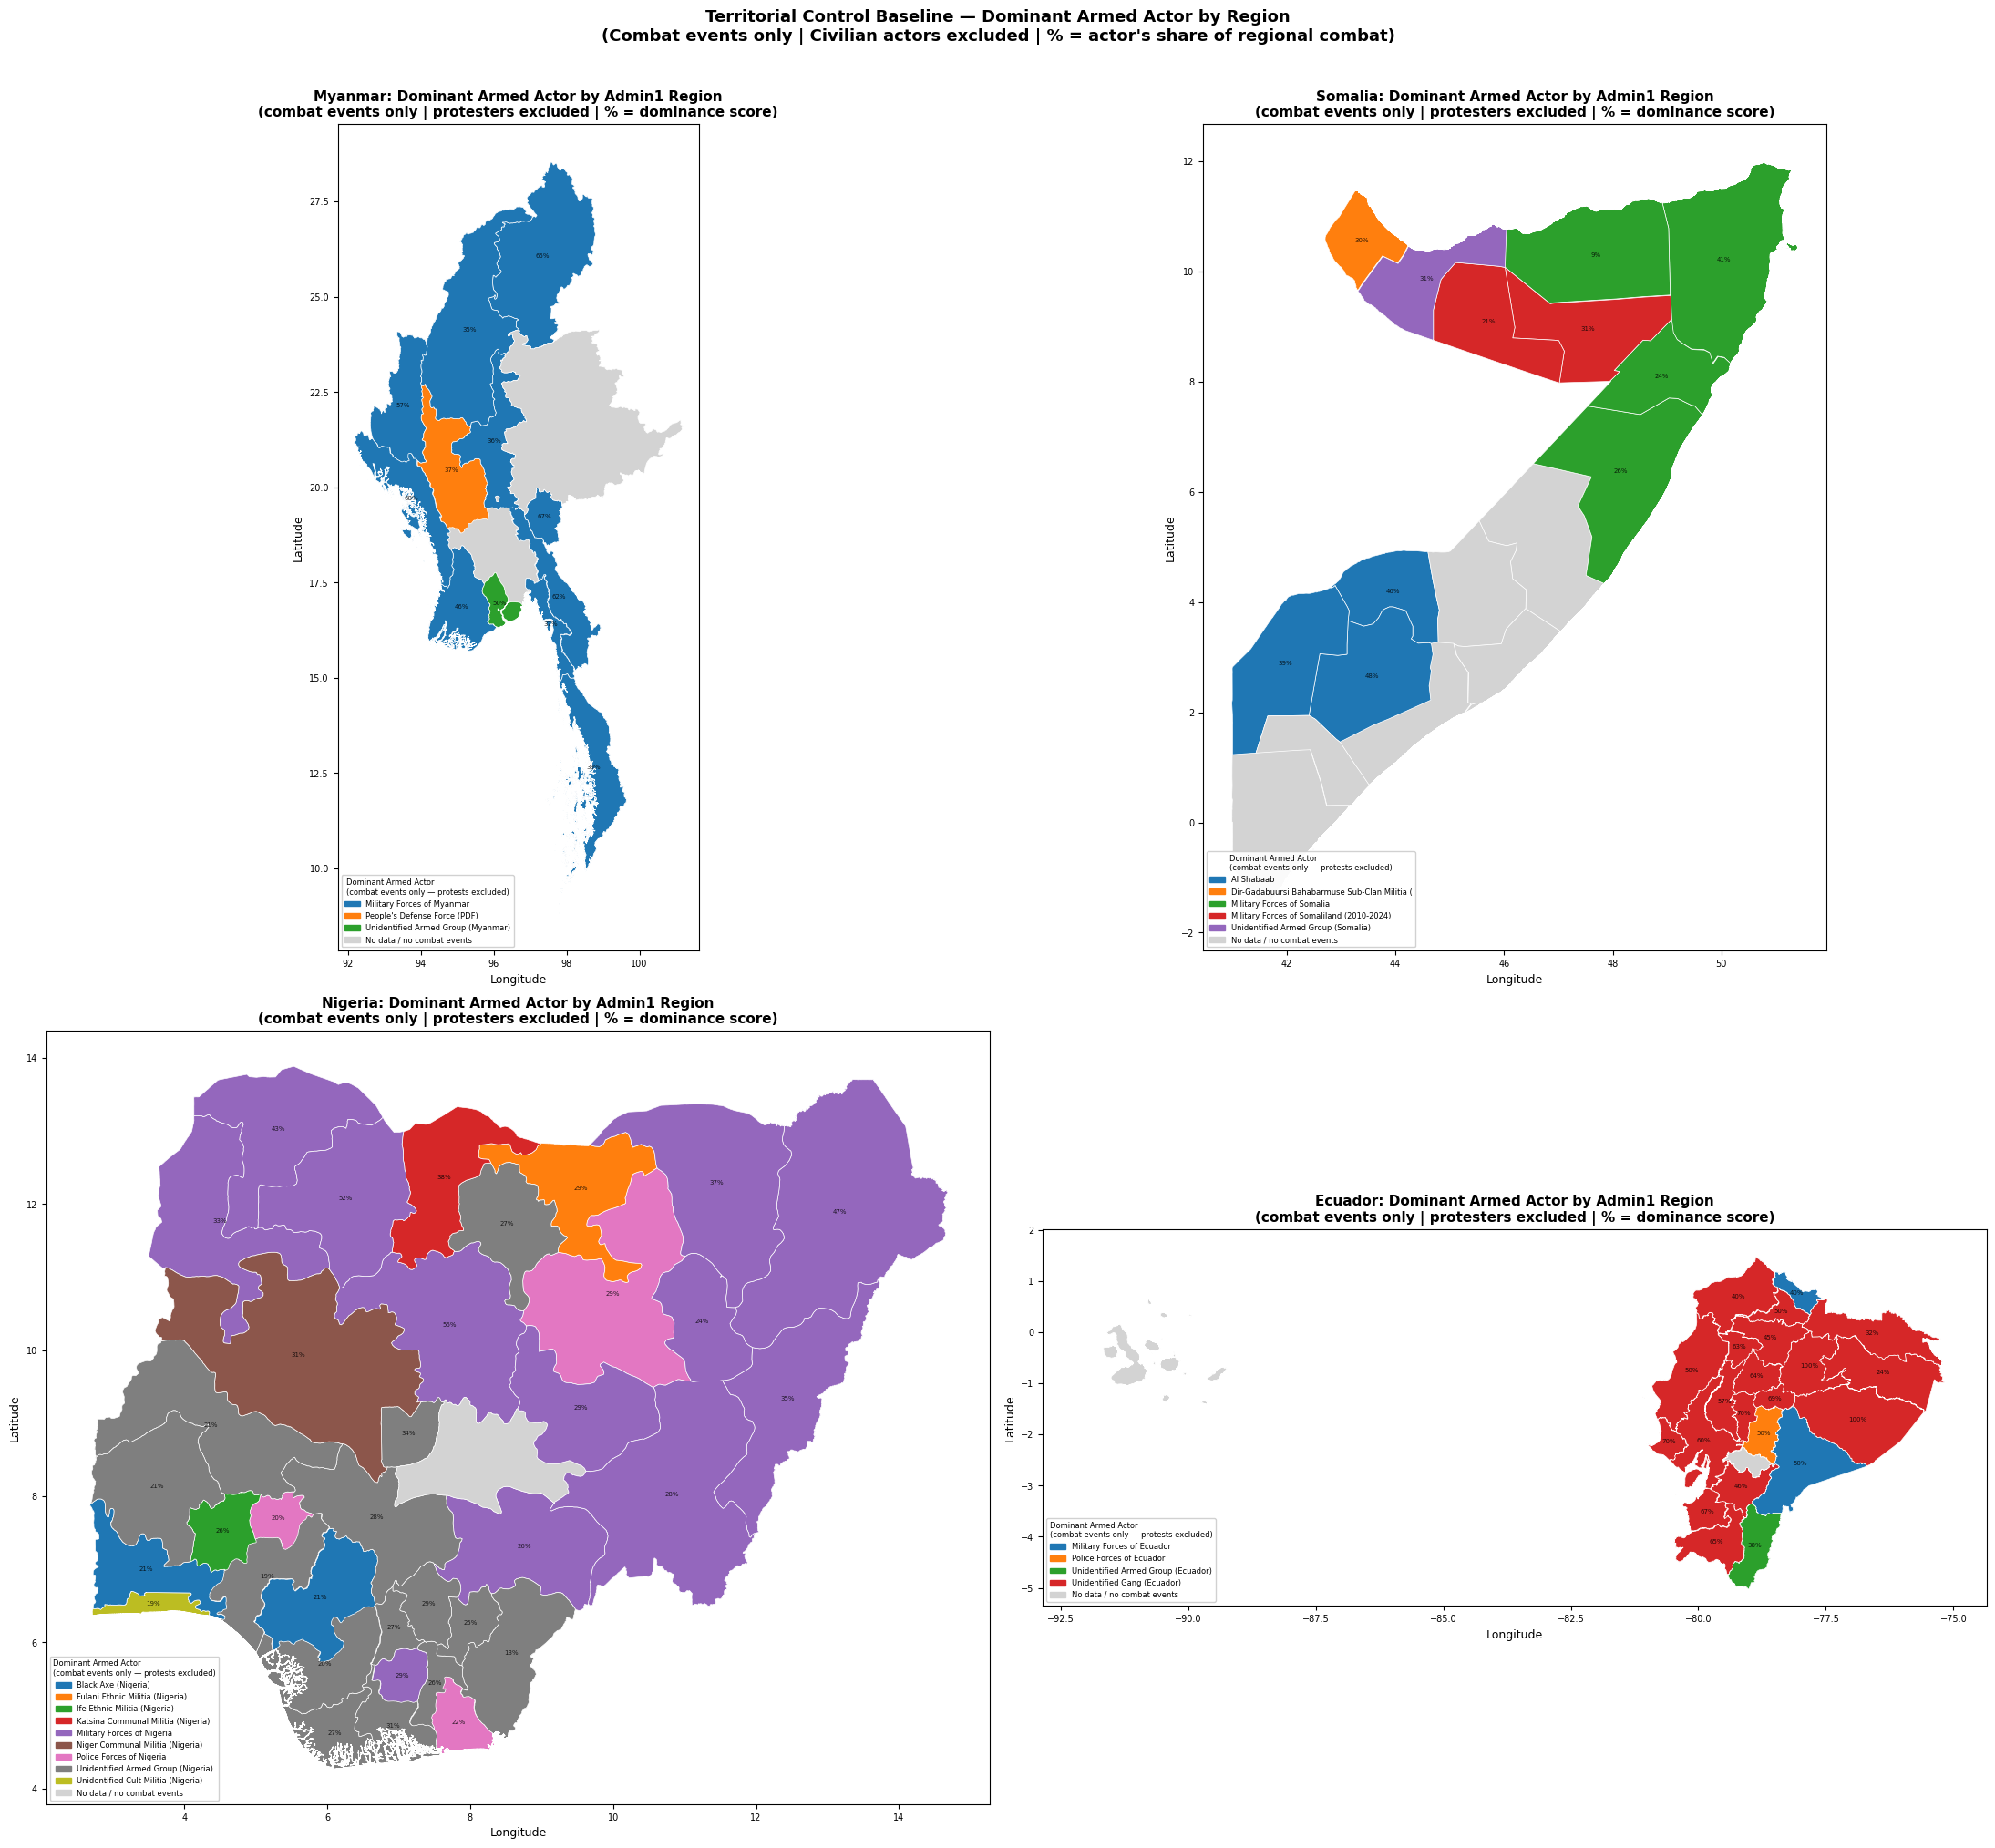

✅ Fixed actor dominance maps saved — combat only, consistent colours


In [46]:
# ── CELL 14: Visualise Actor Dominance on Maps ────────────────────────────────
# CONCEPT: We join our dominance dataframe to the GADM boundary polygons
# to produce choropleth maps (= maps where regions are coloured by a variable).
# Each region is coloured by its dominant actor. This is our FIRST territorial
# control map — the baseline before any HMM or ML modelling.

# ── CELL 14 FIXED: Actor Dominance Maps With Consistent Colours ───────────────
# FIX A: Build one explicit colour dictionary first, use it for BOTH map AND legend
#         This guarantees legend colours always match region colours
# FIX B: Uses dominance_combat (combat only, no protesters) from Cell 13

import geopandas as gpd                        # spatial data for reading boundary files
import matplotlib.patches as mpatches          # used to build manual legend colour patches

# ── GADM FILE PATHS — one GeoPackage per country ──────────────────────────────

gadm_files = {                                 # dictionary: country → (file, layer, name column)
    "Myanmar": (                               # Myanmar entry
        RAW_GADM / "gadm41_MMR.gpkg",          # path to Myanmar GeoPackage
        "ADM_ADM_1",                           # layer name = admin level 1 (state/region)
        "NAME_1"                               # column in GADM containing region names
    ),
    "Somalia": (                               # Somalia entry
        RAW_GADM / "gadm41_SOM.gpkg",          # path to Somalia GeoPackage
        "ADM_ADM_1",                           # layer name = admin level 1
        "NAME_1"                               # region name column
    ),
    "Nigeria": (                               # Nigeria entry
        RAW_GADM / "gadm41_NGA.gpkg",          # path to Nigeria GeoPackage
        "ADM_ADM_1",                           # layer name = admin level 1
        "NAME_1"                               # region name column
    ),
    "Ecuador": (                               # Ecuador entry
        RAW_GADM / "gadm41_ECU.gpkg",          # path to Ecuador GeoPackage
        "ADM_ADM_1",                           # layer name = admin level 1
        "NAME_1"                               # region name column
    ),
}

fig, axes = plt.subplots(2, 2, figsize=(22, 20))   # 2x2 grid of subplots, one per country
axes = axes.flatten()                               # flatten to 1D list so we can loop with index

for idx, (country, (gadm_path, layer, name_col)) in enumerate(gadm_files.items()):

    ax = axes[idx]                             # get this country's subplot axes

    # ── LOAD GADM BOUNDARY POLYGONS ───────────────────────────────────────────

    try:                                       # wrap in try-catch — file may be missing
        gdf = gpd.read_file(                   # read the GeoPackage into a GeoDataFrame
            gadm_path,                         # path to the .gpkg file
            layer=layer                        # which admin level layer to load
        )
    except Exception as e:                     # if file not found or unreadable
        ax.text(                               # show an error message in the subplot
            0.5, 0.5,                          # position at centre of axes
            f"Could not load {country} GADM\n{e}",  # error text
            transform=ax.transAxes,            # position relative to axes, not data
            ha="center", va="center"           # centre both horizontally and vertically
        )
        continue                               # skip to next country

    # ── GET DOMINANCE DATA FOR THIS COUNTRY ───────────────────────────────────

    dom = dominance_combat[country][           # select relevant columns from dominance data
        ["admin1", "dominant_actor", "dominance_score", "total_combat"]
    ].copy()                                   # .copy() to avoid modifying stored results

    # ── MERGE SPATIAL BOUNDARIES WITH DOMINANCE DATA ──────────────────────────

    gdf_merged = gdf.merge(                    # join GADM polygons with dominance results
        dom,                                   # dominance dataframe to merge in
        left_on=name_col,                      # GADM column containing region names
        right_on="admin1",                     # ACLED column containing region names
        how="left"                             # keep all GADM regions, even if no ACLED data
    )

    # ── BUILD EXPLICIT COLOUR DICTIONARY (THE CORE FIX) ───────────────────────
    # Key insight: we create one colour dict here, then use it for BOTH the map
    # AND the legend — this guarantees they always match

    unique_actors = sorted(                    # get all unique dominant actors, sorted alphabetically
        gdf_merged["dominant_actor"]           # the dominant_actor column
        .dropna()                              # ignore NaN (regions with no ACLED data)
        .unique()                              # get unique values only
        .tolist()                              # convert numpy array to Python list
    )

    palette = sns.color_palette(               # generate one distinct colour per actor
        "tab10",                               # tab10 = 10 distinct colours, good for categorical data
        len(unique_actors)                     # one colour for each unique dominant actor
    )

    actor_colour_map = {                       # build the explicit actor → colour mapping
        actor: palette[i]                      # map each actor to its assigned colour
        for i, actor in enumerate(unique_actors)  # enumerate gives (index, actor) pairs
    }

    # ── APPLY COLOURS TO EACH REGION INDIVIDUALLY ─────────────────────────────
    # We plot each region as its own polygon with its assigned colour
    # This guarantees the colour is correct even when geopandas reindexes

    for _, row in gdf_merged.iterrows():       # loop through every region row

        colour = actor_colour_map.get(         # look up this region's actor in the colour map
            row.get("dominant_actor"),         # .get() returns None if column is missing
            "lightgrey"                        # default colour if actor not in map (no data)
        )

        gpd.GeoDataFrame(                      # create a single-row GeoDataFrame for this region
            [row],                             # the single row as a list
            geometry="geometry",               # specify which column holds the geometry
            crs=gdf.crs                        # use the same coordinate reference system as source
        ).plot(
            ax=ax,                             # draw on the correct subplot
            color=[colour],                    # list of colours — must be a list even for one row
            edgecolor="white",                 # white borders between regions for clarity
            linewidth=0.5                      # thin borders
        )

    # ── ADD DOMINANCE SCORE PERCENTAGE LABELS ─────────────────────────────────

    for _, row in gdf_merged.iterrows():       # loop through every region again for labels

        if pd.isna(row.get("dominance_score")):    # skip regions with no dominance data
            continue                               # go to next row

        if pd.isna(row.get("geometry")):           # skip rows with missing geometry
            continue

        centroid = row["geometry"].centroid    # find the geometric centre of the region polygon

        ax.annotate(                           # add text label at the centroid
            f"{row['dominance_score']:.0f}%",  # text: dominance score as integer percentage
            xy=(centroid.x, centroid.y),       # position: at the centroid
            fontsize=5,                        # very small font to fit inside small regions
            ha="center",                       # horizontally centred on the centroid
            va="center",                       # vertically centred on the centroid
            color="black",                     # black text readable on all background colours
            alpha=0.8                          # slightly transparent to not overpower the colour
        )

    # ── BUILD MANUAL LEGEND USING SAME COLOUR MAP ─────────────────────────────
    # Using mpatches.Patch gives us full control — colour guaranteed to match map

    legend_patches = [                         # build list of legend entries
        mpatches.Patch(                        # one patch = one coloured rectangle in legend
            color=actor_colour_map[actor],     # use SAME colour map as the map — guaranteed match
            label=str(actor)[:45]              # truncate very long actor names for legend readability
        )
        for actor in unique_actors             # one entry per unique dominant actor
    ]

    legend_patches.append(                     # add a grey entry for regions with no data
        mpatches.Patch(
            color="lightgrey",                 # same grey used as default above
            label="No data / no combat events" # explain what grey means
        )
    )

    ax.legend(                                 # add the legend to the subplot
        handles=legend_patches,                # use our manually built patches
        loc="lower left",                      # position: bottom-left corner of subplot
        fontsize=6,                            # small font — many entries may be listed
        framealpha=0.9,                        # slightly transparent legend background
        title="Dominant Armed Actor\n(combat events only — protests excluded)",  # legend title
        title_fontsize=6                       # title font size matches entry size
    )

    ax.set_title(                              # subplot title
        f"{country}: Dominant Armed Actor by Admin1 Region\n"
        f"(combat events only | protesters excluded | % = dominance score)",
        fontsize=11, fontweight="bold"
    )
    ax.set_xlabel("Longitude", fontsize=9)     # x-axis label
    ax.set_ylabel("Latitude", fontsize=9)      # y-axis label
    ax.tick_params(labelsize=7)                # small axis tick labels to reduce clutter

plt.suptitle(                                  # overall title spanning all four subplots
    "Territorial Control Baseline — Dominant Armed Actor by Region\n"
    "(Combat events only | Civilian actors excluded | % = actor's share of regional combat)",
    fontsize=13, fontweight="bold", y=1.01     # y=1.01 places title just above the subplots
)
plt.tight_layout()                             # auto-adjust spacing to prevent label overlap
plt.savefig(                                   # save the figure to disk
    "../reports/figures/05_actor_dominance_maps.png",  
    dpi=150,                                   # 150 dpi = good quality for reports
    bbox_inches="tight"                        # don't clip labels at the figure edges
)
plt.show()                                     # display in the notebook
print("✅ Fixed actor dominance maps saved — combat only, consistent colours")

We first defined which actors are non-territorial by checking for civilian keywords like "Protesters" and "Rioters." The compute_actor_dominance_combat function filters the data to combat events only before grouping — so protests, riots, and strategic developments contribute nothing to the dominance score. The core colour fix happens by building one explicit actor_colour_map dictionary before any plotting begins, then using that same dictionary for both colouring the region polygons and building the legend patches. Because both use the same source, they are guaranteed to match. Each region is plotted individually in its own gpd.GeoDataFrame.plot() call, giving us precise colour control row by row.

Our baseline territorial control maps use combat-event-only actor dominance — filtering out protests, riots, and civilian activities before computing which armed actor is most active in each region. This is methodologically important because including protest events would make protesters appear as 'territorial actors' in urban centres, which is theoretically incoherent — protesters express political dissent but do not hold ground.

We computed an actor dominance score for every admin1 region in each country — defined as the percentage of all events in that region initiated by the single most active actor. We then joined this to GADM boundary polygons and produced choropleth maps where each region is coloured by its dominant actor and labelled with their dominance percentage. This is our baseline territorial control estimate — no modelling, no HMM, just counting. It answers the question: even before sophisticated methods, can we see spatial patterns of actor dominance? These maps are the "before" to which our HMM outputs will be compared.

## Geographic Concentration — Key Findings

**Myanmar:** Sagaing contains 24.8% of all events but only 35.3% military combat dominance — indicating intense multi-actor contestation, not total control. Magway is the only region where the PDF (People's Defense Force) outperforms the military in combat events (37.2%) — the geographic heartland of the anti-junta resistance. Yangon shows Unidentified Armed Group at 49.9% dominance in combat terms — urban guerrilla activity rather than open military confrontation.

**Somalia:** Three territorial zones are visible without any modelling: Al-Shabaab dominates the south (Lower Shabelle 55.7%, Bay 48.4%, Bakool 46.5%); Military Forces of Somalia holds Bari/Puntland (41.4%) and Galgaduud; Military Forces of Somaliland holds Sool (30.8%). These match the known political fragmentation of Somalia precisely.

**Nigeria:** The Nigerian Military dominates combat in the insurgency and banditry zones (Borno 47.3%, Zamfara 51.7%, Kaduna 55.6%). This reflects active counter-insurgency operations rather than territorial control — the military is the most active combat initiator, but it does not hold these regions unchallenged. Katsina is the only major region where a communal militia (Katsina Communal Militia, 37.8%) outperforms the military in combat, indicating a zone where state forces have lower engagement than local armed groups.

**Ecuador:** Gangs dominate all provinces in combat terms — including highland provinces like Azuay (46.0%) and Tungurahua (68.6%) which previously appeared protest-dominated when all events were counted. The highland/protest distinction is an artefact of counting all events; in combat terms, Ecuador is uniformly gang-controlled.

**Methodological note:** Grey regions on the maps indicate zero recorded combat events in ACLED — this is ambiguous between two interpretations: (1) total uncontested control with no armed challenge, or (2) a reporting gap where ACLED has insufficient source coverage. Both are possible and cannot be distinguished from event data alone.

# Deep Dive 3: Actor-Specific Time Series

The dominance maps showed WHERE each actor is most active. This analysis shows WHEN. By plotting monthly event counts per actor over the full time series, we can identify: when did an actor emerge, peak, fragment, or collapse? Combined with the spatial maps, we get the two dimensions of territorial control: location and timing.

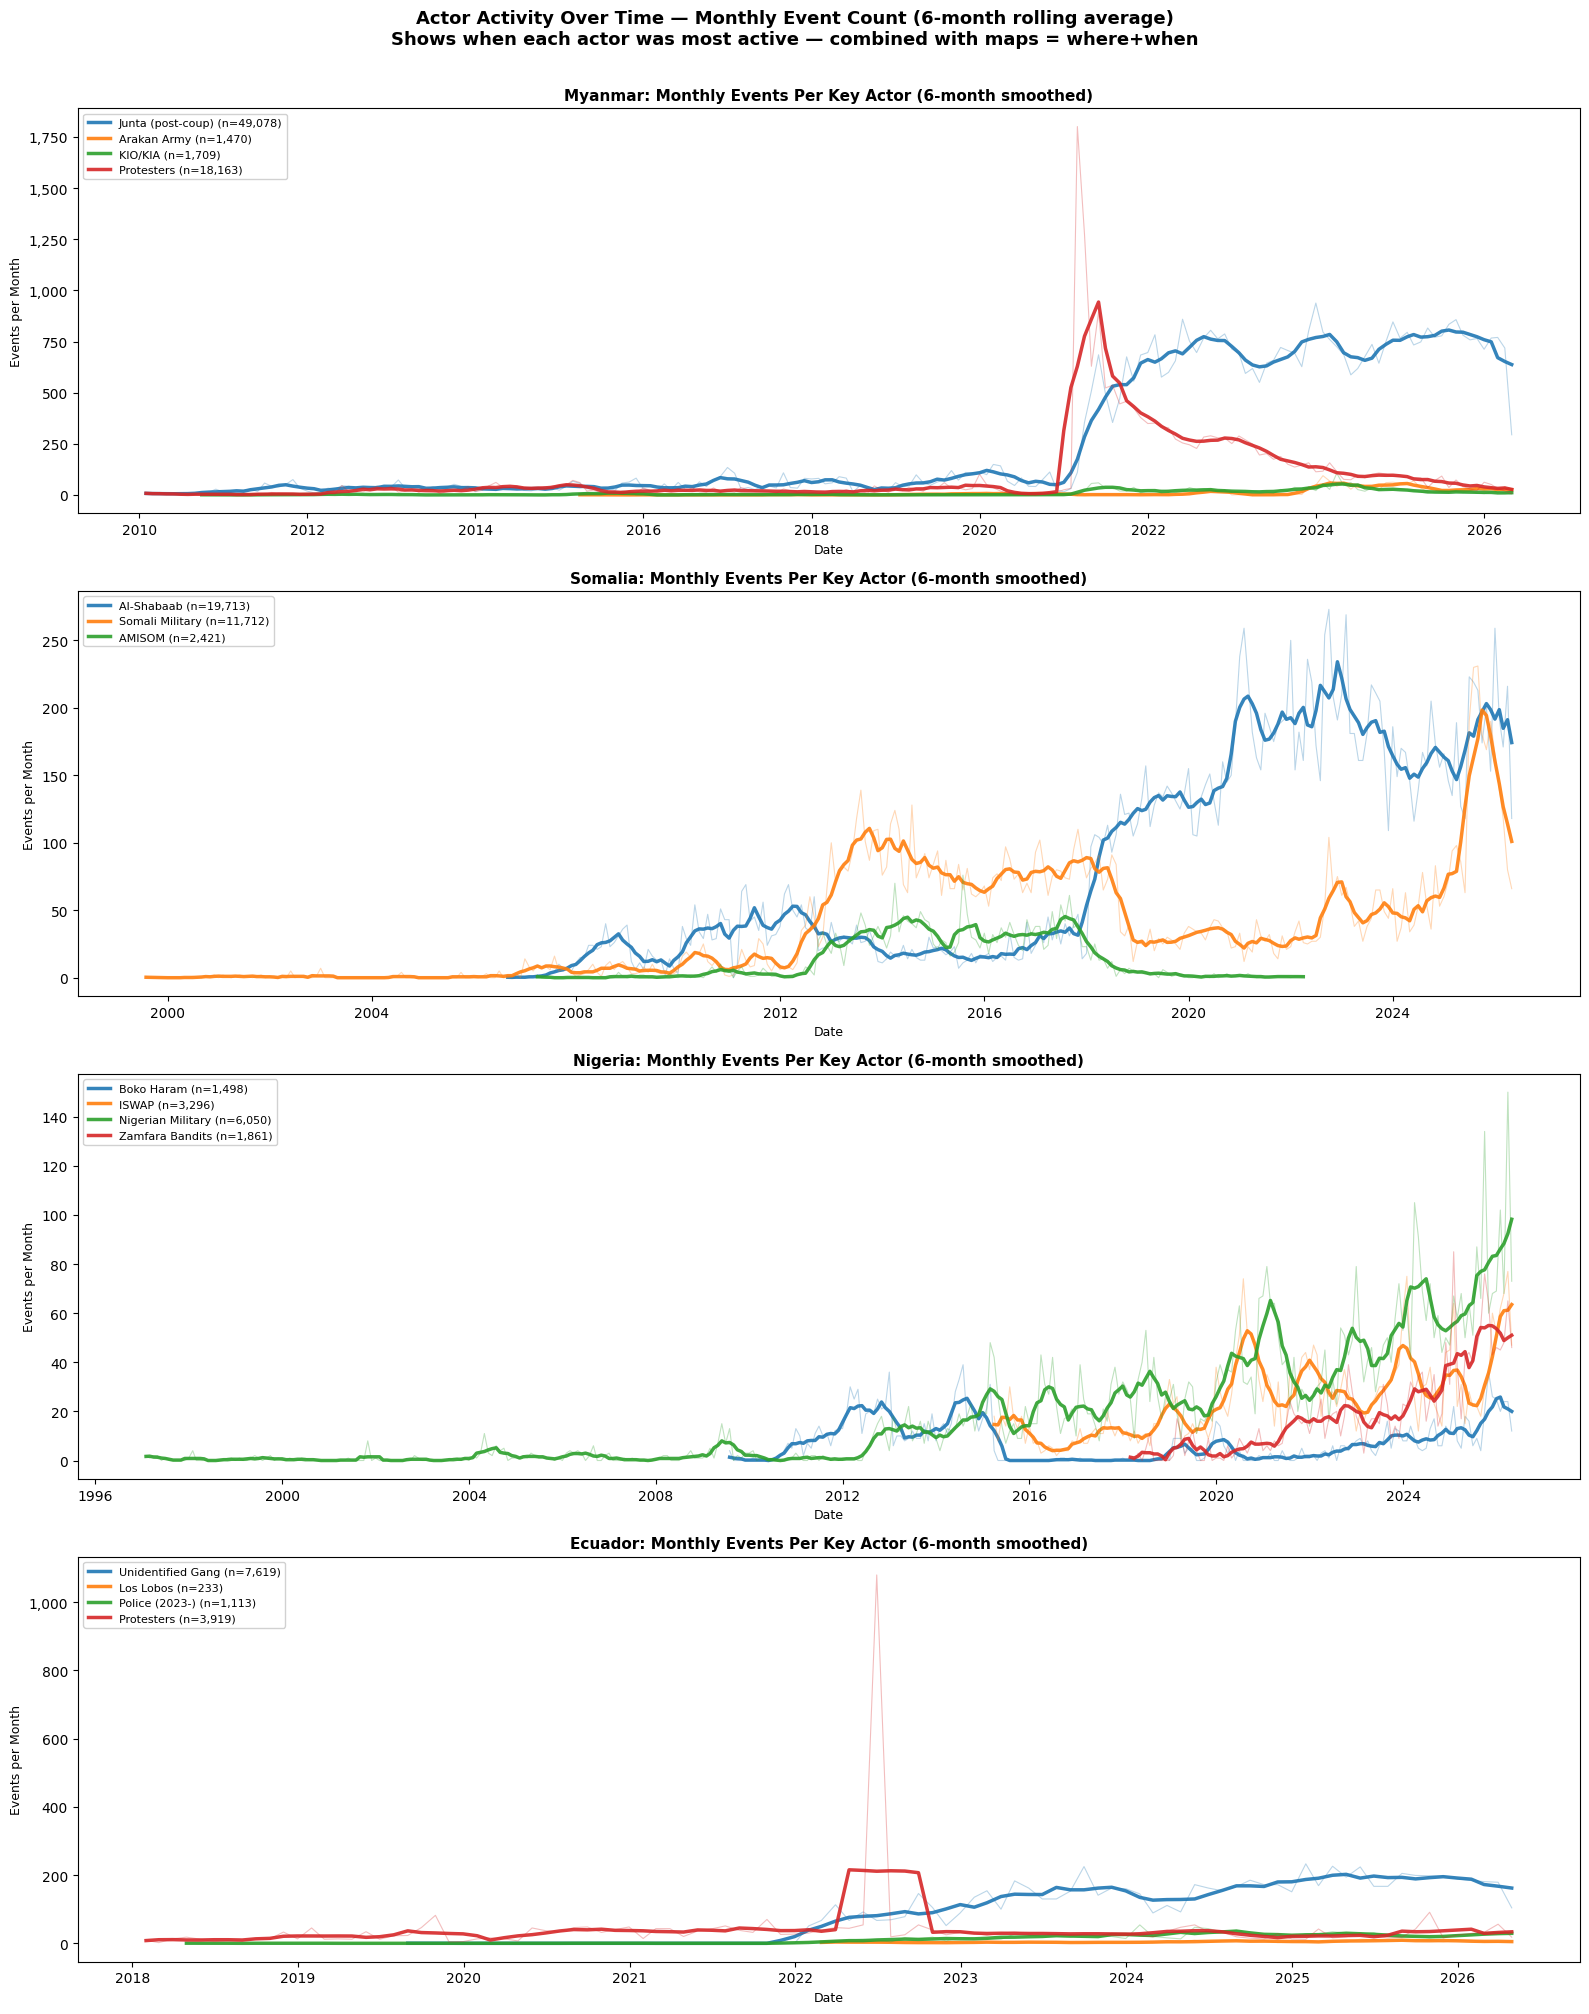

✅ Actor time series saved


In [ ]:
# ── CELL 15: Option B — Actor-Specific Time Series ────────────────────────────
# CONCEPT: Instead of all events per month, we plot specific ACTORS over time.
# This shows us: when did an actor's activity peak? When did it collapse?
# Combined with the dominance maps, this tells us both WHERE and WHEN
# each actor was most active — the two dimensions of territorial control.

focus_actor_timeseries = {
    "Myanmar": {                                   # Myanmar: track the three main forces
        "Military Forces of Myanmar": "Myanmar Military (all periods)",
        "ULA/AA: United League of Arakan/Arakan Army": "Arakan Army",
        "KIO/KIA: Kachin Independence Organization/Kachin Independence Army": "KIO/KIA",
        "Protesters (Myanmar)": "Protesters",
    },
    "Somalia": {                                   # Somalia: track Al-Shabaab vs state forces
        "Al Shabaab": "Al-Shabaab",
        "Military Forces of Somalia": "Somali Military",
        "AMISOM": "AMISOM",
        #"Military Forces of Somalia": "Somali Military (2022-)",
    },
    "Nigeria": {                                   # Nigeria: track insurgent vs state vs communal
        "Boko Haram - Jamaatu Ahli is-Sunnah lid-Dawati wal-Jihad": "Boko Haram",
        "ISWAP": "ISWAP",
        "Military Forces of Nigeria": "Nigerian Military",
        "Zamfara Communal Militia (Nigeria)": "Zamfara Bandits",
    },
    "Ecuador": {                                   # Ecuador: track gang vs state
        "Unidentified Gang (Ecuador)": "Unidentified Gang",
        "Los Lobos Gang (Ecuador)": "Los Lobos",
        "Police Forces of Ecuador": "Police (2023-)",
        "Protesters (Ecuador)": "Protesters",
    },
}

fig, axes = plt.subplots(4, 1, figsize=(16, 20))   # four tall subplots, one per country

for idx, (country, actors_dict) in enumerate(focus_actor_timeseries.items()):

    ax = axes[idx]                                 # this country's axes
    df = acled[country].copy()                     # get the country dataframe
    df = df.set_index("event_date")               # set date as index for resampling
    colors = sns.color_palette("tab10", len(actors_dict))  # distinct colours

    for (actor_full, actor_label), color in zip(actors_dict.items(), colors):

        # Filter to this specific actor using regex=False
        actor_events = df[
            df["actor1"].str.contains(actor_full, case=False, na=False, regex=False)
        ]

        if len(actor_events) < 10:                 # skip actors with very few events
            print(f"  ⚠️  {country}: '{actor_label}' has only {len(actor_events)} events — skipping")
            continue

        monthly = (
            actor_events["fatalities"]             # select fatalities column
            .resample("ME")                        # resample to month-end
            .count()                               # count events per month
            .reset_index()
            .rename(columns={"fatalities": "events"})
        )

        smoothed = (                               # 6-month rolling average for trend clarity
            monthly["events"]
            .rolling(window=6, min_periods=2, center=True)
            .mean()
        )

        ax.plot(                                   # raw monthly events — thin transparent
            monthly["event_date"],
            monthly["events"],
            color=color, linewidth=0.8, alpha=0.3,
            label="_nolegend_"
        )

        ax.plot(                                   # smoothed trend — thick visible line
            monthly["event_date"],
            smoothed,
            color=color, linewidth=2.5, alpha=0.9,
            label=f"{actor_label} (n={len(actor_events):,})"  # show total event count in legend
        )

    ax.set_title(
        f"{country}: Monthly Events Per Key Actor (6-month smoothed)",
        fontsize=11, fontweight="bold"
    )
    ax.set_ylabel("Events per Month", fontsize=9)
    ax.set_xlabel("Date", fontsize=9)
    ax.legend(loc="upper left", fontsize=8, framealpha=0.9)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda y, _: f"{int(y):,}")  # comma-formatted numbers
    )

plt.suptitle(
    "Actor Activity Over Time — Monthly Event Count (6-month rolling average)\n"
    "Shows when each actor was most active — combined with maps = where+when",
    fontsize=13, fontweight="bold", y=1.005
)
plt.tight_layout()
plt.savefig("../reports/figures/06_actor_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Actor time series saved")

## 🇲🇲 Myanmar — The Military's Full Institutional History Now Visible

After actor consolidation, the Myanmar Military line (blue, n=49,078) now spans 2010–2026 — covering pre-coup counter-insurgency, the coup period, and the ongoing civil war. This reveals the full institutional story: relatively stable activity 2010–2020, then an explosion post-February 2021.

**Protesters (red) peaked before the Military ramped up** — the protest movement reached ~1,000 events/month by mid-2021 and then collapsed as military repression intensified. This sequencing matters: the data shows the population resisted first, and the military escalated in response.

**Arakan Army (orange) and KIO/KIA (green)** are nearly invisible at this scale (~20–30 events/month) but their dominance maps showed them controlling entire regions. This is the key methodological insight: **event count is not the same as territorial control.** A small number of high-significance battles can control more territory than a large number of scattered skirmishes. Our HMM handles this correctly by using patterns, not just volume.


## 🇸🇴 Somalia — Three Phases of State-Building

After consolidation, the Somali Military (orange, n=11,712) is now one continuous line covering all brackets from 2004 to 2026 — the full institutional history of Somalia's armed forces across multiple government transitions.

Three distinct phases are visible:
- **2007–2016:** Somali Military and Al-Shabaab escalate together, with AMISOM providing the backbone of counter-insurgency capacity.
- **2016–2022:** AMISOM activity peaks then declines as the mission mandate approaches its end; Somali forces gradually absorb responsibilities.
- **2022–2026:** Al-Shabaab surges to 200+ events/month — its highest level in the dataset — precisely as AMISOM formally transitions to ATMIS and then ends. The security handover created a window that Al-Shabaab exploited.

This three-phase pattern is one of the clearest conflict dynamics signals in our entire dataset.


## 🇳🇬 Nigeria — Fragmentation After 2019

Before 2019, Boko Haram largely dominated. After 2019, four actors converge at similar activity levels: Boko Haram declines, ISWAP grows, the Nigerian Military escalates, and Zamfara Bandits emerge from near zero.

This is the fragmentation of Nigeria's conflict — from one dominant insurgency to a four-way contested landscape. The Zamfara Bandits rising from zero around 2018 and reaching parity with the other actors by 2025 is only visible because we downloaded data back to 1997 — it gives the new conflict thread its full context.

**Note:** Boko Haram's event count (n=1,498) is lower than expected due to our ISWAP consolidation rule absorbing ambiguous "ISWAP and/or Boko Haram" combined entries. This is documented as a methodological choice.


## 🇪🇨 Ecuador — Three Phases in Six Years

The Ecuador chart is the most compressed story in the dataset — dramatic change in a short window:
1. **Near-zero baseline (2018–2021):** Ecuador looked peaceful.
2. **January 2023 protest spike:** ~1,000 events in one month — the national strike and protest wave. After this, protests collapse sharply.
3. **2023–2026 gang consolidation:** Unidentified Gang becomes the dominant persistent signal; Police appear prominently only after the state of emergency declaration.

The sequence — **protest, then gang war, then state militarisation** — is encoded in this single chart. Ecuador went from one of South America's safer countries to an active criminal war zone in approximately 18 months.

# Deep Dive 4: Fatality Efficiency — Average Deaths Per Event by Actor

Event counts tell us how active an actor is. Fatality efficiency tells us how *lethal* each event is. An actor with 0.1 deaths/event conducts frequent but low-lethality activity (skirmishes, checkpoints). An actor with 40 deaths/event conducts mass-casualty operations (massacres, mass executions). These are independent dimensions — a highly active actor is not necessarily the most deadly one.

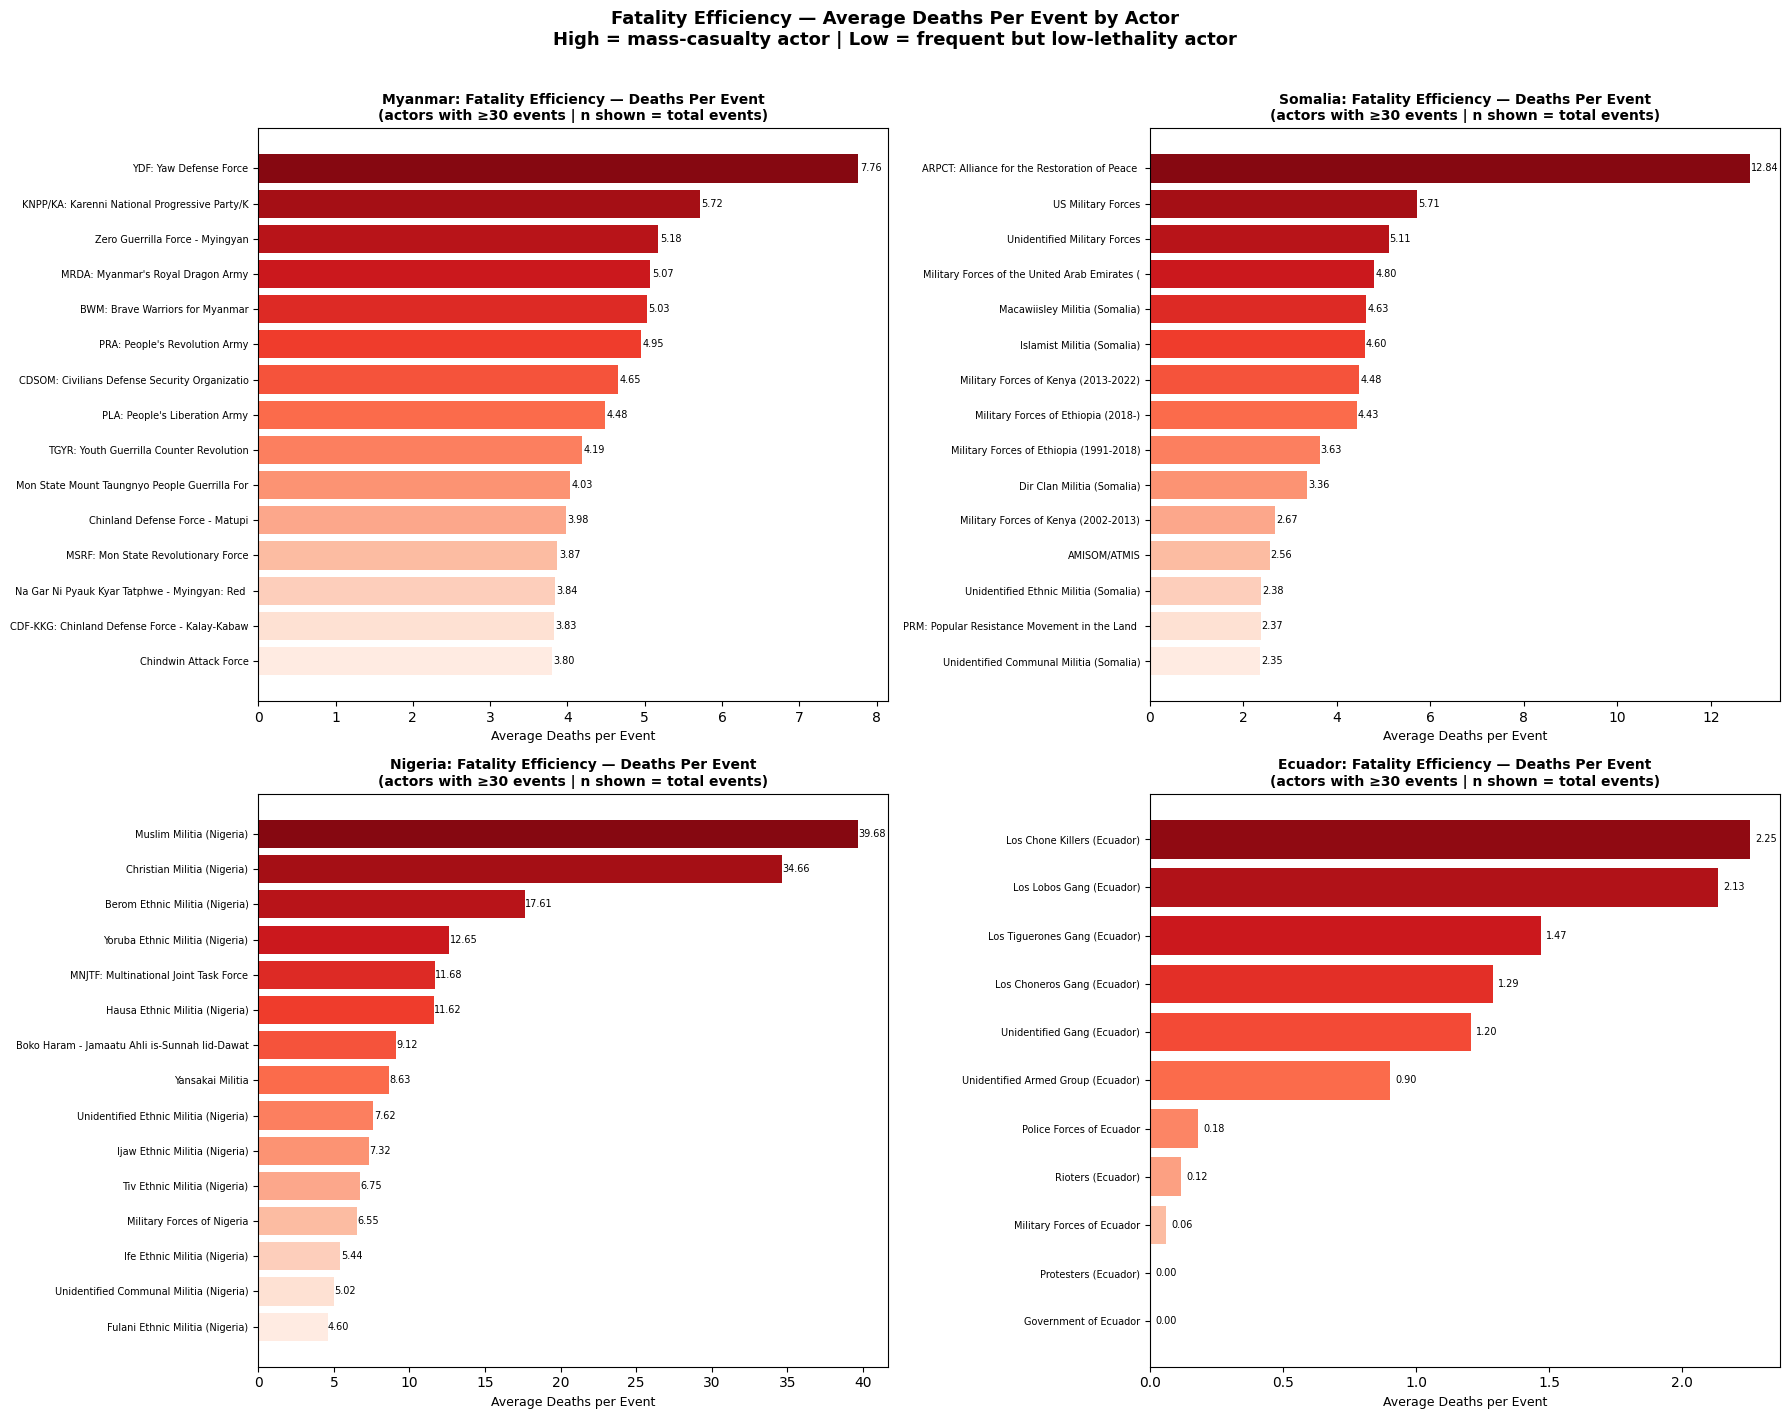

✅ Fatality efficiency chart saved


In [42]:
# ── CELL 16: Option E — Fatality Efficiency Per Actor ─────────────────────────
# CONCEPT: "Fatality efficiency" = average deaths per event for each actor.
# An actor with 0.1 deaths/event = mostly non-lethal activity (protests, skirmishes)
# An actor with 50 deaths/event = conducts mass-casualty attacks
# This reveals TACTICAL PROFILES — how each actor uses violence.
# High efficiency = targeted, lethal operations (airstrikes, mass executions)
# Low efficiency = frequent but low-lethality activity (harassment, skirmishes)

def compute_fatality_efficiency(df: pd.DataFrame, min_events: int = 20) -> pd.DataFrame:
    """
    Compute average fatalities per event for each actor.
    
    Parameters:
    - df: country dataframe
    - min_events: minimum events required to include actor (default 20)
    
    Returns: dataframe sorted by fatality efficiency descending
    """

    actor_stats = (
        df.groupby("actor1")                   # group by initiating actor
        .agg(
            total_events=("fatalities", "count"),   # count total events
            total_fatalities=("fatalities", "sum"),  # sum total deaths caused
            max_single_event=("fatalities", "max"),  # deadliest single event
        )
        .reset_index()
    )

    actor_stats = actor_stats[                 # filter to actors with enough events
        actor_stats["total_events"] >= min_events
    ].copy()

    actor_stats["deaths_per_event"] = (        # fatality efficiency = deaths / events
        actor_stats["total_fatalities"] / actor_stats["total_events"]
    )

    return actor_stats.sort_values(            # sort by efficiency descending
        "deaths_per_event", ascending=False
    )

# Compute and display for all countries
fatality_results = {}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))   # 2x2 grid
axes = axes.flatten()

for idx, (country, df) in enumerate(acled.items()):

    efficiency = compute_fatality_efficiency(df, min_events=30)  # min 30 events
    fatality_results[country] = efficiency     # store for later use

    ax = axes[idx]

    top15 = efficiency.head(15)                # top 15 most lethal actors

    bars = ax.barh(                            # horizontal bar chart
        range(len(top15)),                     # y positions
        top15["deaths_per_event"],             # bar length = deaths per event
        color=sns.color_palette("Reds_r", len(top15))  # red palette — darker = more lethal
    )

    ax.set_yticks(range(len(top15)))           # set y tick positions
    ax.set_yticklabels(                        # set y tick labels
        [str(a)[:45] for a in top15["actor1"]],  # truncate long names
        fontsize=7
    )

    # Add value labels on each bar
    for bar, (_, row) in zip(bars, top15.iterrows()):
        ax.text(
            bar.get_width() + 0.02,            # position just right of bar end
            bar.get_y() + bar.get_height()/2,  # vertically centred on bar
            f"{row['deaths_per_event']:.2f}",  # show deaths per event value
            va="center", fontsize=7            # vertically centred text
        )

    ax.set_title(
        f"{country}: Fatality Efficiency — Deaths Per Event\n"
        f"(actors with ≥30 events | n shown = total events)",
        fontsize=10, fontweight="bold"
    )
    ax.set_xlabel("Average Deaths per Event", fontsize=9)
    ax.invert_yaxis()                          # highest efficiency at top

plt.suptitle(
    "Fatality Efficiency — Average Deaths Per Event by Actor\n"
    "High = mass-casualty actor | Low = frequent but low-lethality actor",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("../reports/figures/07_fatality_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Fatality efficiency chart saved")

## 🇲🇲 Myanmar — Small Resistance Groups Are the Deadliest Per Event

**YDF (Yaw Defense Force): 7.76 deaths per event**

This is a small local People's Defense Force unit — not the junta and not one of the major ethnic armies. Myanmar's most lethal actors *per event* are small local resistance groups, not the largest named organisations.

The Myanmar military — now consolidated across all periods, with **49,078 total events** — does not appear in the top 15 efficiency actors. This makes sense: the military conducts thousands of low-lethality operations (airstrikes on infrastructure, checkpoints, arrests) which drag down its per-event average even though its absolute fatality count is very high.

**Thesis implication:** High event count and high lethality per event are independent dimensions. The HMM should treat fatality efficiency and event frequency as separate input features, not as proxies for each other.


## 🇸🇴 Somalia — External Military Forces Are Disproportionately Lethal

- **ARPCT (Alliance for the Restoration of Peace): 12.84 deaths per event**
  A Somali warlord coalition active in the mid-2000s. Its extreme efficiency reflects the targeted nature of its operations during a brief but intense period.

- **US Military Forces: 5.71 deaths per event**
  After consolidating all US military year brackets, this is the corrected average. American airstrikes and special operations in Somalia are low-frequency but very high-lethality — the second most lethal actor type in the dataset. Scientifically important and politically sensitive to document in the World Bank report.

- **AMISOM/ATMIS: 2.56 deaths per event**
  After consolidating AMISOM and its successor mission ATMIS into one canonical actor, the average drops significantly from the pre-consolidation figure (7.02). This is correct and expected: the ATMIS phase was a lower-intensity security transition rather than active offensive operations. The consolidated number reflects the institution's full operational history more honestly.


## 🇳🇬 Nigeria — Religious Militias Are Catastrophically Lethal

- **Muslim Militia (Nigeria): 39.68 deaths per event**
- **Christian Militia (Nigeria): 34.66 deaths per event**

These are off-the-chart outliers compared to every other actor across all four countries. Nigeria's communal religious violence — farmer-herder clashes and village massacres — is the most lethal per-event activity in the entire dataset.

For context, **Boko Haram at 9.12 deaths per event** is less than a quarter as lethal per event as the religious militias. The most internationally publicised insurgency is not the most lethal form of violence in per-event terms. This is a major policy-relevant finding for the World Bank: the violence that receives the most attention is not the violence that kills the most people per incident.


## 🇪🇨 Ecuador — Named Gangs More Lethal Than Unidentified

- **Los Chone Killers: 2.25 deaths per event**
- **Los Lobos: 2.13 deaths per event**

Named, identified gangs are more lethal per event than the generic "Unidentified Gang (Ecuador)" at 1.20. This is consistent with targeted assassinations of rival gang members versus general territorial skirmishes.

- **Police and Military:** near zero (0.06–0.19 deaths per event) — operating in law enforcement mode, not warfare mode
- **Protesters:** 0.00 deaths per event — entirely non-lethal, confirming they should be excluded from the territorial control model

**Cross-country comparison:** Ecuador's maximum efficiency (2.25) is an order of magnitude below Nigeria's (39.68) and Somalia's (12.84). Criminal territorial warfare is lethal but structurally less mass-casualty than insurgency or communal warfare. This distinction matters for how we parameterise the HMM across countries.

# Complete EDA Summary

## Deep Dive 1 — Conventional Ratio
✅ Al-Shabaab: ratio drops to 0% precisely at 2010-11 AMISOM offensive → theory confirmed
✅ Myanmar Military: 0.711 original → 0.981 refined (+0.270) → airstrikes reclassified as state power
✅ Ecuador gangs: mean 0.734 → open territorial warfare, not assassination → method transfers
✅ Myanmar coup visible as tactical break: ratio was HIGH pre-2021, drops post-coup as airstrikes escalate
⚠️  Boko Haram: inverted pattern → expansion via civilian raids, not battles → limitation documented
⚠️  AMISOM/ATMIS: zero change in refinement → inter1 not coded as "State forces" for international forces → documented as edge case

## Deep Dive 2 — Geographic Concentration (combat events only)
✅ Sagaing = 24.8% of all Myanmar events → civil war epicentre confirmed
✅ Magway = only region where PDF outperforms military in combat (37.2%) → resistance heartland
✅ Somalia: 3 territorial zones confirmed — Al-Shabaab south, Military Forces of Somalia northeast, Somaliland northwest
✅ Nigeria: Military dominates insurgency zones in combat; communal militias dominate banditry belt (Zamfara 51.7%, Katsina 37.8%)
✅ Ecuador: gangs dominate ALL provinces in combat terms — highland/protest distinction only holds for all-event counts, not combat events
✅ Three methodological fixes applied: combat-only events, protesters excluded, legend colours consistent
⚠️  Grey regions = reporting gaps OR total control — ambiguity cannot be resolved from event data alone

## Deep Dive 3 — Actor Time Series
✅ Myanmar: protesters peaked BEFORE military escalation → civil resistance preceded crackdown
✅ Somalia: AMISOM decline and Somali Military consolidation visible as 2022 torch-pass
✅ Nigeria: Zamfara Bandits emerged 2018 from zero → new conflict thread only visible with full history
✅ Ecuador: protest spike Jan 2023 → gang war → state militarisation — full sequence in one chart
KEY INSIGHT: Event count ≠ territorial control (Arakan Army: ~20 events/month, controls all of Rakhine)

## Deep Dive 4 — Fatality Efficiency
✅ Nigeria religious militias: 35-40 deaths/event → most lethal per-event actors in the entire dataset
✅ US Military in Somalia: 5.71 deaths/event (corrected after consolidation) → high-lethality low-frequency operations
✅ AMISOM/ATMIS: 2.56 deaths/event (corrected after consolidation) — lower than pre-consolidation because ATMIS phase is now included
✅ Ecuador named gangs more lethal than unidentified (2.25 vs 1.20) → targeted assassination vs diffuse violence
✅ Ecuador protesters: 0.00 deaths/event → entirely non-lethal → confirmed correct to exclude from control model
KEY FINDING: High event frequency and high lethality are independent dimensions — never use one as a proxy for the other

## Methodological Implications for HMM
- Use **refined conv_ratio** (actor-type-aware, airstrikes reclassified) as primary emission variable
- Use **fatality efficiency** as a secondary feature — captures lethality independent of frequency
- Use **admin1 combat dominance score** as baseline validation benchmark for model output
- **Exclude protest and riot events** from territorial control model entirely
- **Flag grey map regions** as data uncertainty — do not interpret as confirmed peace
- **Document Nigeria religious militia pattern** separately — communal violence follows different logic than insurgency
- **Actor consolidation** applied before all analysis — merges time-bracketed ACLED institutional identities